# [EDA] 그룹 1 — 경기 시점·선수·팀 종합 분석

그룹 1의 12개 피처와 제구 성공률의 관계를 중요도 순서로 확인한다. 각 절은 **목적 → 방법 → 코드와 출력 → 결과와 결론** 순서로 읽는다.

분석 단위는 투구 직전 상태 1행이고 `control_success=1`은 제구 성공이다. 아래 결과는 관찰된 관계이며 인과관계를 뜻하지 않는다.


## 분석 준비

필요한 컬럼만 읽고 데이터 무결성을 확인한 뒤, 이닝 구간·손 유형 조합·이닝 구간 내부 상대 LI 4등분을 만든다. 이 셀들은 결과가 아니라 뒤의 집계를 재현하기 위한 준비 코드다.


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=r"Glyph .* missing from font")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["svg.fonttype"] = "none"
plt.rcParams.update({
    "figure.figsize": (11, 5),
    "axes.titlesize": 13,
    "axes.labelsize": 10,
    "figure.dpi": 110,
})

def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "data" / "train.csv").exists():
            return candidate
    raise FileNotFoundError("data/train.csv가 있는 프로젝트 루트를 찾지 못했습니다.")

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
DATA_PATH = PROJECT_ROOT / "data" / "train.csv"
EDA_ASSET_DIR = PROJECT_ROOT / "outputs" / "group1_eda"
EDA_ASSET_DIR.mkdir(parents=True, exist_ok=True)

TARGET = "control_success"
GROUP1 = [
    "season", "game_month", "game_dayofweek", "inning", "top_bottom", "game_type",
    "pitcher_id", "batter_id", "pitcher_hand", "batter_hand",
    "pitcher_team_id", "batter_team_id",
]
CUMULATIVE_RATE_COLS = [
    "asof_pitcher_success_rate",
    "asof_batter_success_rate",
]
RECENT_SUCCESS_COLS = [
    "asof_pitcher_prev1_game_success_rate",
    "asof_pitcher_prev3_game_success_rate",
    "asof_pitcher_prev5_game_success_rate",
]
COUNT_COLS = ["asof_pitcher_n", "asof_batter_n"]
CONTEXT_COLS = [
    "li", "score_diff_home", "score_diff_pitcher_team", "base_state", "num_runners_on",
    "home_win_expectancy", "away_win_expectancy",
]
PITCHMIX_COLS = [
    "asof_pitcher_pitchmix_n", "asof_pitcher_fastball_rate",
    "asof_pitcher_breaking_rate", "asof_pitcher_offspeed_rate",
]
USECOLS = ["row_id", TARGET, *GROUP1, *CUMULATIVE_RATE_COLS, *RECENT_SUCCESS_COLS,
           *COUNT_COLS, *CONTEXT_COLS, *PITCHMIX_COLS]

def wilson_interval(successes, n, z=1.96):
    successes = np.asarray(successes, dtype=float)
    n = np.asarray(n, dtype=float)
    p = np.divide(successes, n, out=np.full_like(successes, np.nan), where=n > 0)
    denom = 1 + z**2 / n
    center = (p + z**2 / (2*n)) / denom
    margin = z * np.sqrt((p*(1-p) + z**2/(4*n)) / n) / denom
    return center - margin, center + margin

def aggregate_rate(frame, by):
    out = frame.groupby(by, observed=True)[TARGET].agg(n="size", successes="sum", success_rate="mean").reset_index()
    out["ci_low"], out["ci_high"] = wilson_interval(out["successes"], out["n"])
    return out

HISTORY_LABELS = {
    "asof_pitcher_success_rate": "투수의 투구 직전 누적 제구 성공률",
    "asof_batter_success_rate": "타자가 직전까지 상대한 투구의 누적 제구 성공률",
    "asof_pitcher_prev1_game_success_rate": "투수의 직전 1경기 제구 성공률",
    "asof_pitcher_prev3_game_success_rate": "투수의 직전 3경기 제구 성공률",
    "asof_pitcher_prev5_game_success_rate": "투수의 직전 5경기 제구 성공률",
}

def readable_rate_table(frame, group_labels=None):
    """집계 계산용 열을 사람에게 읽기 쉬운 백분율 표로 바꾼다."""
    out = frame.copy()
    for column in ["success_rate", "ci_low", "ci_high"]:
        if column in out:
            out[column] = out[column] * 100
    labels = {
        "n": "투구 수",
        "successes": "제구 성공 투구 수",
        "success_rate": "제구 성공률(%)",
        "ci_low": "95% 신뢰구간 하한(%)",
        "ci_high": "95% 신뢰구간 상한(%)",
    }
    if group_labels:
        labels.update(group_labels)
    return out.rename(columns=labels)

print(f"Project root: {PROJECT_ROOT}")
print(f"Pandas {pd.__version__} | NumPy {np.__version__}")


Project root: /Users/heowonjun/Documents/project/lgaimers
Pandas 2.3.3 | NumPy 2.2.6


In [2]:
all_columns = pd.read_csv(DATA_PATH, nrows=0, encoding="utf-8-sig").columns.tolist()
missing_requested = sorted(set(USECOLS) - set(all_columns))
assert not missing_requested, f"필수 컬럼 누락: {missing_requested}"

df = pd.read_csv(DATA_PATH, usecols=USECOLS, encoding="utf-8-sig", low_memory=False)
for col in ["top_bottom", "game_type", "base_state"]:
    df[col] = df[col].astype("category")

integrity = pd.Series({
    "rows": len(df),
    "original_columns": len(all_columns),
    "loaded_columns": len(df.columns),
    "duplicate_row_id": int(df["row_id"].duplicated().sum()),
    "target_missing": int(df[TARGET].isna().sum()),
    "target_min": int(df[TARGET].min()),
    "target_max": int(df[TARGET].max()),
    "overall_success_rate": float(df[TARGET].mean()),
    "memory_mb": float(df.memory_usage(deep=True).sum() / 1024**2),
}, name="value")
integrity_display = integrity.rename(index={
    "rows": "전체 투구 행 수",
    "original_columns": "원본 열 수",
    "loaded_columns": "이번 분석에서 읽은 열 수",
    "duplicate_row_id": "중복 row_id 수",
    "target_missing": "제구 성공 여부 결측 수",
    "target_min": "제구 성공 여부 최솟값",
    "target_max": "제구 성공 여부 최댓값",
    "overall_success_rate": "전체 투구 제구 성공률(0~1)",
    "memory_mb": "메모리 사용량(MB)",
}).to_frame("값")
display(integrity_display)

assert len(df) == 1_475_092, "공식 배포본과 행 수가 다릅니다."
assert df["row_id"].is_unique, "row_id가 고유하지 않습니다."
assert set(df[TARGET].unique()) <= {0, 1}, "타깃이 이진값이 아닙니다."
print("무결성 검사 통과")

,값
전체 투구 행 수,"1,475,092.0000"
원본 열 수,49.0000
이번 분석에서 읽은 열 수,32.0000
중복 row_id 수,0.0000
제구 성공 여부 결측 수,0.0000
제구 성공 여부 최솟값,0.0000
제구 성공 여부 최댓값,1.0000
전체 투구 제구 성공률(0~1),0.5238
메모리 사용량(MB),417.8082


무결성 검사 통과


In [3]:
def observed_values(series, max_items=15):
    values = series.dropna().unique()
    if len(values) <= max_items:
        return ", ".join(map(str, sorted(values.tolist())))
    return f"{series.min()} ~ {series.max()}"

quality = pd.DataFrame({
    "dtype": df[GROUP1].dtypes.astype(str),
    "n_unique": df[GROUP1].nunique(dropna=True),
    "missing_pct": df[GROUP1].isna().mean().mul(100),
    "observed": [observed_values(df[c]) for c in GROUP1],
})
display(quality.rename(columns={
    "dtype": "자료형",
    "n_unique": "관측된 값 종류 수",
    "missing_pct": "결측률(%)",
    "observed": "관측값 또는 범위",
}).rename_axis("변수명"))

assert quality["missing_pct"].eq(0).all(), "그룹 1 원본 피처에 결측이 있습니다."
print("그룹 1의 12개 원본 피처 결측률은 모두 0%입니다.")

,자료형,관측된 값 종류 수,결측률(%),관측값 또는 범위
변수명,,,,
season,int64,6,0.0000,"2019, 2020, 2021, 2022, 2023, 2024"
game_month,int64,8,0.0000,"3, 4, 5, 6, 7, 8, 9, 10"
game_dayofweek,int64,7,0.0000,"0, 1, 2, 3, 4, 5, 6"
inning,int64,13,0.0000,"1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13"
top_bottom,category,2,0.0000,"B, T"
game_type,category,2,0.0000,"F, R"
pitcher_id,int64,792,0.0000,20700 ~ 24633
batter_id,int64,830,0.0000,20889 ~ 24632
pitcher_hand,int64,2,0.0000,"1, 2"


그룹 1의 12개 원본 피처 결측률은 모두 0%입니다.


In [4]:
# 1) 이닝·손 조합 집계축
inning_labels = ["1-3", "4-6", "7-9", "Extra"]
df["inning_phase"] = pd.cut(
    df["inning"], bins=[0, 3, 6, 9, np.inf], labels=inning_labels, ordered=True
)
df["hand_matchup"] = (
    df["pitcher_hand"].astype(str) + "-" + df["batter_hand"].astype(str)
).astype("category")
df["same_hand_code"] = df["pitcher_hand"].eq(df["batter_hand"])

# 2) 학습 구간에서 처음 관측된 시즌과 과거 기록 부족 여부 표시
pitcher_first_observed_season_by_id = df.groupby("pitcher_id", observed=True)["season"].min()
batter_first_observed_season_by_id = df.groupby("batter_id", observed=True)["season"].min()
df["pitcher_first_observed_season"] = df["pitcher_id"].map(pitcher_first_observed_season_by_id)
df["batter_first_observed_season"] = df["batter_id"].map(batter_first_observed_season_by_id)
df["pitcher_first_seen_in_season"] = df["season"].eq(df["pitcher_first_observed_season"])
df["batter_first_seen_in_season"] = df["season"].eq(df["batter_first_observed_season"])

# 3) 같은 이닝 구간 안에서 낮음→높음을 비교하기 위한 상대 4등분
df["li_within_inning_quantile_band"] = pd.Series(index=df.index, dtype="object")
li_within_phase_edges = []
for phase in inning_labels:
    mask = df["inning_phase"].eq(phase)
    values = df.loc[mask, "li"]
    quantiles = values.quantile([0, .25, .50, .75, 1])
    edges = np.unique(quantiles.to_numpy())
    labels = [f"Q{i}" for i in range(1, len(edges))]
    df.loc[mask, "li_within_inning_quantile_band"] = pd.cut(
        values, bins=edges, labels=labels, include_lowest=True, duplicates="drop"
    ).astype("object")
    li_within_phase_edges.append({
        "inning_phase": phase,
        "LI_min": quantiles.loc[0],
        "LI_q25": quantiles.loc[.25],
        "LI_q50": quantiles.loc[.50],
        "LI_q75": quantiles.loc[.75],
        "LI_max": quantiles.loc[1],
    })

df["li_within_inning_quantile_band"] = pd.Categorical(
    df["li_within_inning_quantile_band"],
    categories=["Q1", "Q2", "Q3", "Q4"],
    ordered=True,
)

assert df["inning_phase"].notna().all()
assert df["hand_matchup"].notna().all()
assert df["li_within_inning_quantile_band"].notna().all()
print("분석용 이닝 구간·손 유형 조합·상대 LI 구간 생성 완료")


분석용 이닝 구간·손 유형 조합·상대 LI 구간 생성 완료


## 결론

| 우선순위 | 관계 | 판단 |
|---|---|---|
| 높음 | `season` | 2019년 56.47%에서 2024년 48.61%로 성공률이 7.86%p 하락했다. |
| 높음 | `inning`과 경기 상황 | LI가 높을수록 성공률이 낮아지는 단순 관계는 없지만, LI 구간이 달라도 후반 이닝 성공률은 낮다. |
| 높음 | 투수 손 유형 × 타자 손 유형 × 과거 구종 구성 | 손 유형은 단독값보다 맞대결 조합에서 차이가 커지고, 과거 구종 구성과의 조건부 관계도 확인된다. |
| 조건부 | 선수 ID × 과거 표본 수 × 누적 성공률 | 선수별 차이는 있으나 소표본과 새 선수에 취약하며 누적률은 시즌 하락을 늦게 반영한다. |
| 조건부 | 경기 유형·월·팀 ID | 경기 유형·월은 시즌에 따라 관계가 달라지고, 팀 ID는 작은 표본과 선수 구성·이동이 섞여 고정된 능력으로 해석하기 어렵다. |
| 낮음 | 요일·초/말 단독 효과 | 화~일 차이와 초/말 차이가 작다. |

가장 먼저 검증할 축은 시즌, 이닝, 손 유형 조합이다. ID와 팀 ID는 그대로 외우게 하지 않고 과거 표본 수·시즌 정보와 함께 검증한다.


## 0. 12개 피처 단독 EDA

**목적:** 상호작용을 보기 전에 12개 피처 각각의 값별 투구 수와 제구 성공률을 확인한다.

**방법:** 값 종류가 적은 10개 피처는 관측값을 모두 집계한다. 투수·타자 ID는 모든 ID를 산점도로 표시하고 표본 수에 따른 성공률 변동을 확인한다.


### 0.1 시간·경기 정보 6개

시즌, 월, 요일, 이닝, 초/말, 경기 유형의 모든 관측값에 대해 투구 수와 제구 성공률을 비교한다.


[season] 시즌


,피처,값,투구 수,투구 비중(%),제구 성공률(%),전체 평균 대비(%p)
0,season,2019,237413,16.0948,56.4670,4.0904
1,season,2020,244087,16.5472,53.2712,0.8946
2,season,2021,247088,16.7507,53.2762,0.8996
3,season,2022,247472,16.7767,52.8920,0.5154
4,season,2023,245525,16.6447,49.9957,-2.3809
5,season,2024,253507,17.1858,48.6105,-3.7661


[game_month] 월


,피처,값,투구 수,투구 비중(%),제구 성공률(%),전체 평균 대비(%p)
6,game_month,3,25756,1.7461,53.7506,1.3740
7,game_month,4,206638,14.0085,52.5963,0.2197
8,game_month,5,255547,17.3241,53.2290,0.8524
9,game_month,6,253454,17.1823,52.6979,0.3213
10,game_month,7,177147,12.0092,52.1110,-0.2656
11,game_month,8,221570,15.0208,51.9023,-0.4743
12,game_month,9,227845,15.4462,52.0626,-0.3140
13,game_month,10,107135,7.2629,50.9171,-1.4595


[game_dayofweek] 요일 코드(0=월요일)


...

[top_bottom] 초(T)·말(B)


,피처,값,투구 수,투구 비중(%),제구 성공률(%),전체 평균 대비(%p)
34,top_bottom,B,722280,48.9651,52.4443,0.0677
35,top_bottom,T,752812,51.0349,52.3116,-0.0650


[game_type] 경기 유형 코드


,피처,값,투구 수,투구 비중(%),제구 성공률(%),전체 평균 대비(%p)
36,game_type,F,161004,10.9148,60.3271,7.9505
37,game_type,R,1314088,89.0852,51.4025,-0.9741


,피처,전체 값 수,최저 성공률 값,최저값 투구 수,최저 성공률(%),최고 성공률 값,최고값 투구 수,최고 성공률(%),최고-최저 차이(%p)
0,season,6,2024,253507,48.6105,2019,237413,56.4670,7.8565
1,game_month,8,10,107135,50.9171,3,25756,53.7506,2.8335
2,game_dayofweek,7,0,14754,49.9661,5,252121,52.4708,2.5047
3,inning,13,11,5441,50.3768,1,172012,53.2079,2.8311
4,top_bottom,2,T,752812,52.3116,B,722280,52.4443,0.1327
5,game_type,2,R,1314088,51.4025,F,161004,60.3271,8.9246


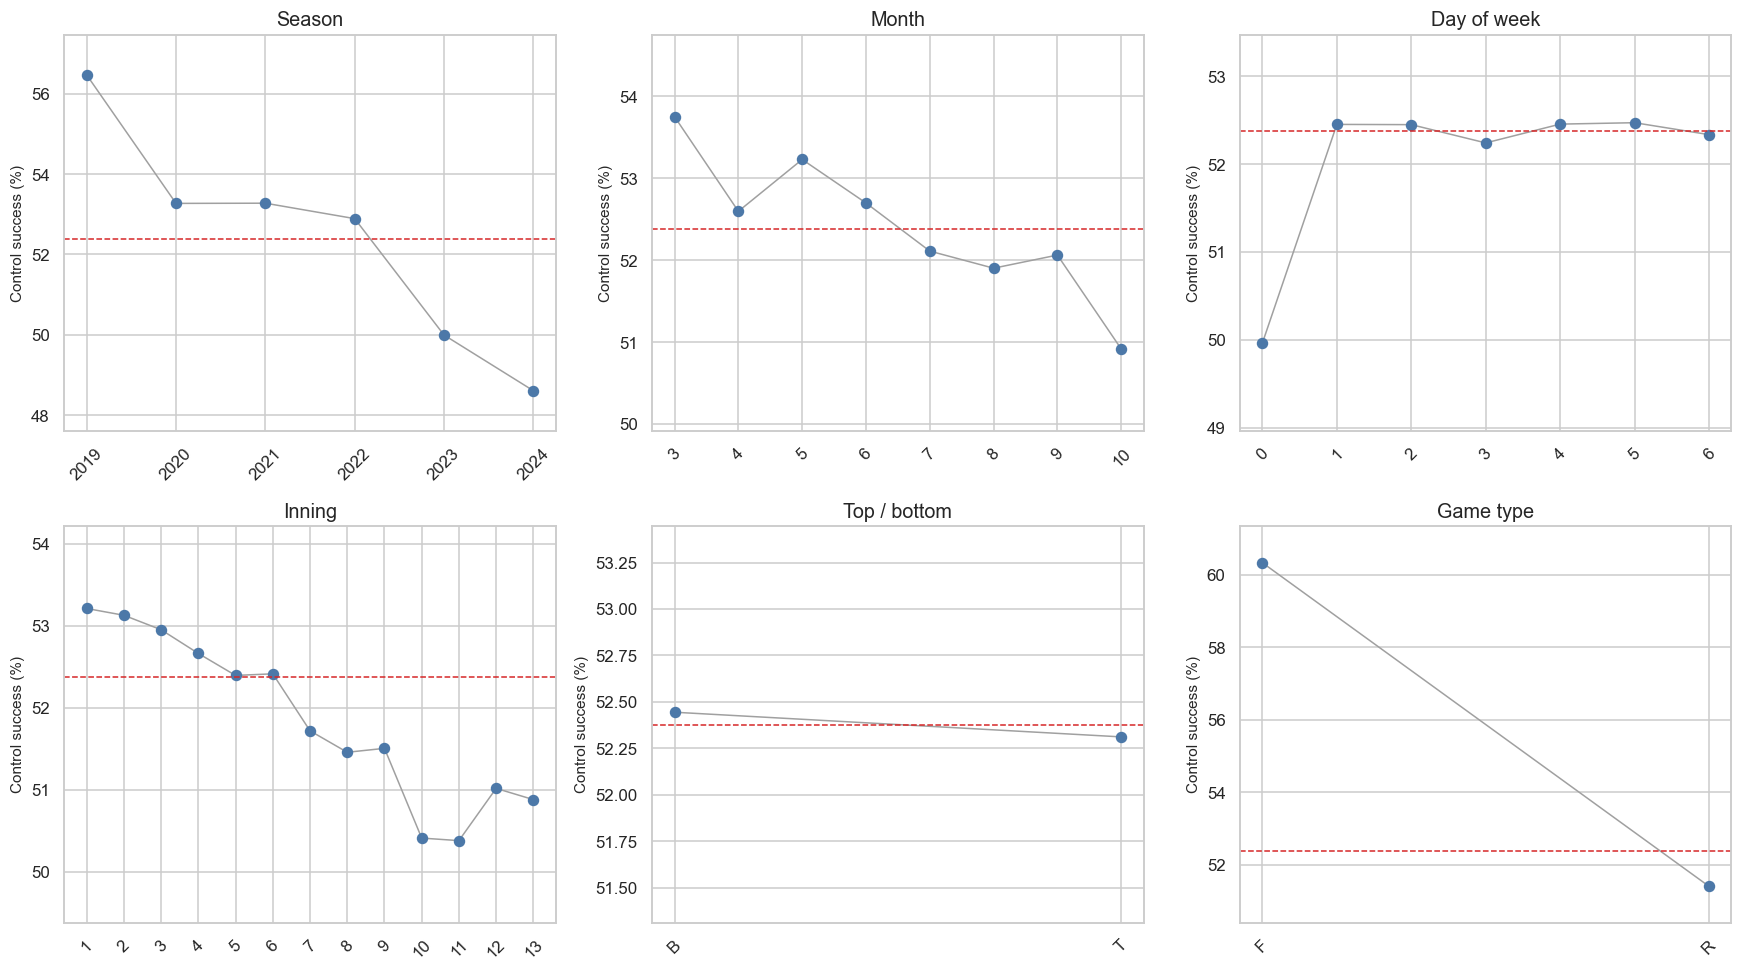


**결론:** 시간·경기 정보에서는 시즌 **7.86%p**와 이닝의 차이가 우선 검증 대상이다. 초/말 차이는 **0.13%p**로 작고, 월과 경기 유형은 시즌별 분석에서 방향의 반복 여부를 확인한다.


In [5]:
pitcher_stats = aggregate_rate(df, "pitcher_id").merge(
    df.groupby("pitcher_id", observed=True)["season"].nunique().rename("n_seasons").reset_index(),
    on="pitcher_id",
)
batter_stats = aggregate_rate(df, "batter_id").merge(
    df.groupby("batter_id", observed=True)["season"].nunique().rename("n_seasons").reset_index(),
    on="batter_id",
)

standalone_features = [
    'season', 'game_month', 'game_dayofweek', 'inning', 'top_bottom', 'game_type',
    'pitcher_hand', 'batter_hand', 'pitcher_team_id', 'batter_team_id',
]
standalone_labels = {
    'season': '시즌', 'game_month': '월', 'game_dayofweek': '요일 코드(0=월요일)',
    'inning': '정확한 이닝', 'top_bottom': '초(T)·말(B)', 'game_type': '경기 유형 코드',
    'pitcher_hand': '투수 손 유형 코드', 'batter_hand': '타자 손 유형 코드',
    'pitcher_team_id': '투수 팀 ID', 'batter_team_id': '타자 팀 ID',
}
overall_rate = df[TARGET].mean()
standalone_parts = []
for feature in standalone_features:
    part = aggregate_rate(df, feature).rename(columns={feature: '값'})
    part.insert(0, '피처', feature)
    part['투구 비중(%)'] = part['n'] / len(df) * 100
    part['제구 성공률(%)'] = part['success_rate'] * 100
    part['전체 평균 대비(%p)'] = (part['success_rate'] - overall_rate) * 100
    standalone_parts.append(part[['피처', '값', 'n', '투구 비중(%)', '제구 성공률(%)', '전체 평균 대비(%p)']])
standalone_value_summary = pd.concat(standalone_parts, ignore_index=True)

spread_rows = []
for feature in standalone_features:
    part = standalone_value_summary.loc[standalone_value_summary['피처'].eq(feature)]
    min_row = part.loc[part['제구 성공률(%)'].idxmin()]
    max_row = part.loc[part['제구 성공률(%)'].idxmax()]
    spread_rows.append({
        '피처': feature, '전체 값 수': len(part),
        '최저 성공률 값': min_row['값'], '최저값 투구 수': int(min_row['n']),
        '최저 성공률(%)': min_row['제구 성공률(%)'],
        '최고 성공률 값': max_row['값'], '최고값 투구 수': int(max_row['n']),
        '최고 성공률(%)': max_row['제구 성공률(%)'],
        '최고-최저 차이(%p)': max_row['제구 성공률(%)'] - min_row['제구 성공률(%)'],
    })
standalone_spread = pd.DataFrame(spread_rows)

def plot_standalone(ax, feature, title):
    part = standalone_value_summary.loc[standalone_value_summary['피처'].eq(feature)].copy()
    part['값 라벨'] = part['값'].astype(str)
    x = np.arange(len(part))
    y = part['제구 성공률(%)'].to_numpy()
    ax.plot(x, y, color='#A0A0A0', linewidth=1, zorder=1)
    ax.scatter(x, y, color='#4C78A8', s=42, zorder=2)
    ax.axhline(overall_rate * 100, color='#D62728', linestyle='--', linewidth=1)
    ax.set_xticks(x, part['값 라벨'])
    lower = min(y.min(), overall_rate * 100) - 1
    upper = max(y.max(), overall_rate * 100) + 1
    ax.set_ylim(lower, upper)
    ax.set_title(title)
    ax.set_xlabel('')
    ax.set_ylabel('Control success (%)')
    ax.tick_params(axis='x', rotation=45)


for feature in standalone_features[:6]:
    print(f"[{feature}] {standalone_labels[feature]}")
    display(standalone_value_summary.loc[standalone_value_summary["피처"].eq(feature)].rename(columns={"n": "투구 수"}))
display(standalone_spread.loc[standalone_spread["피처"].isin(standalone_features[:6])])

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, feature, title in zip(axes.flat, standalone_features[:6], ['Season', 'Month', 'Day of week', 'Inning', 'Top / bottom', 'Game type']):
    plot_standalone(ax, feature, title)
fig.tight_layout()
fig.savefig(EDA_ASSET_DIR / 'group1_standalone_time_context.svg', bbox_inches='tight')
plt.show()


display(Markdown(f"""
**결론:** 시간·경기 정보에서는 시즌 **{standalone_spread.set_index('피처').loc['season', '최고-최저 차이(%p)']:.2f}%p**와 이닝의 차이가 우선 검증 대상이다. 초/말 차이는 **{standalone_spread.set_index('피처').loc['top_bottom', '최고-최저 차이(%p)']:.2f}%p**로 작고, 월과 경기 유형은 시즌별 분석에서 방향의 반복 여부를 확인한다.
"""))


### 0.2 손 유형·팀 ID 4개

투수·타자 손 유형과 투수·타자 팀 ID의 모든 관측값을 비교한다. 손 유형은 뒤에서 맞대결 조합으로, 팀 ID는 상대 팀 조합과 선수 이동으로 다시 확인한다.


[pitcher_hand] 투수 손 유형 코드


,피처,값,투구 수,투구 비중(%),제구 성공률(%),전체 평균 대비(%p)
38,pitcher_hand,1,381351,25.8527,51.6705,-0.7061
39,pitcher_hand,2,1093741,74.1473,52.6228,0.2462


[batter_hand] 타자 손 유형 코드


,피처,값,투구 수,투구 비중(%),제구 성공률(%),전체 평균 대비(%p)
40,batter_hand,1,695747,47.1663,52.0939,-0.2827
41,batter_hand,2,779345,52.8337,52.6289,0.2523


[pitcher_team_id] 투수 팀 ID


,피처,값,투구 수,투구 비중(%),제구 성공률(%),전체 평균 대비(%p)
42,pitcher_team_id,12,145926,9.8927,53.1235,0.7469
43,pitcher_team_id,13,208662,14.1457,53.8699,1.4933
44,pitcher_team_id,14,141953,9.6233,52.1553,-0.2213
45,pitcher_team_id,15,137418,9.3159,51.9699,-0.4067
46,pitcher_team_id,16,136193,9.2328,51.5797,-0.7969
47,pitcher_team_id,17,148166,10.0445,52.1577,-0.2189
48,pitcher_team_id,18,137000,9.2876,54.0460,1.6694
49,pitcher_team_id,19,137001,9.2876,50.5792,-1.7974
50,pitcher_team_id,20,130574,8.8519,52.0104,-0.3662
51,pitcher_team_id,21,146794,9.9515,51.1935,-1.1831


[batter_team_id] 타자 팀 ID


,피처,값,투구 수,투구 비중(%),제구 성공률(%),전체 평균 대비(%p)
55,batter_team_id,12,142405,9.6540,51.8156,-0.5610
56,batter_team_id,13,213325,14.4618,53.6698,1.2932
57,batter_team_id,14,145937,9.8934,52.0958,-0.2808
58,batter_team_id,15,134524,9.1197,52.1550,-0.2216
59,batter_team_id,16,135581,9.1914,52.2809,-0.0957
60,batter_team_id,17,144335,9.7848,52.3435,-0.0331
61,batter_team_id,18,134642,9.1277,51.8872,-0.4894
62,batter_team_id,19,135761,9.2036,52.0518,-0.3248
63,batter_team_id,20,139297,9.4433,52.1957,-0.1809
64,batter_team_id,21,143335,9.7170,52.2071,-0.1695


,피처,전체 값 수,최저 성공률 값,최저값 투구 수,최저 성공률(%),최고 성공률 값,최고값 투구 수,최고 성공률(%),최고-최저 차이(%p)
6,pitcher_hand,2,1,381351,51.6705,2,1093741,52.6228,0.9523
7,batter_hand,2,1,695747,52.0939,2,779345,52.6289,0.5350
8,pitcher_team_id,13,25,292,42.4658,22,676,69.2308,26.7650
9,batter_team_id,13,25,292,48.2877,22,773,68.4347,20.1470


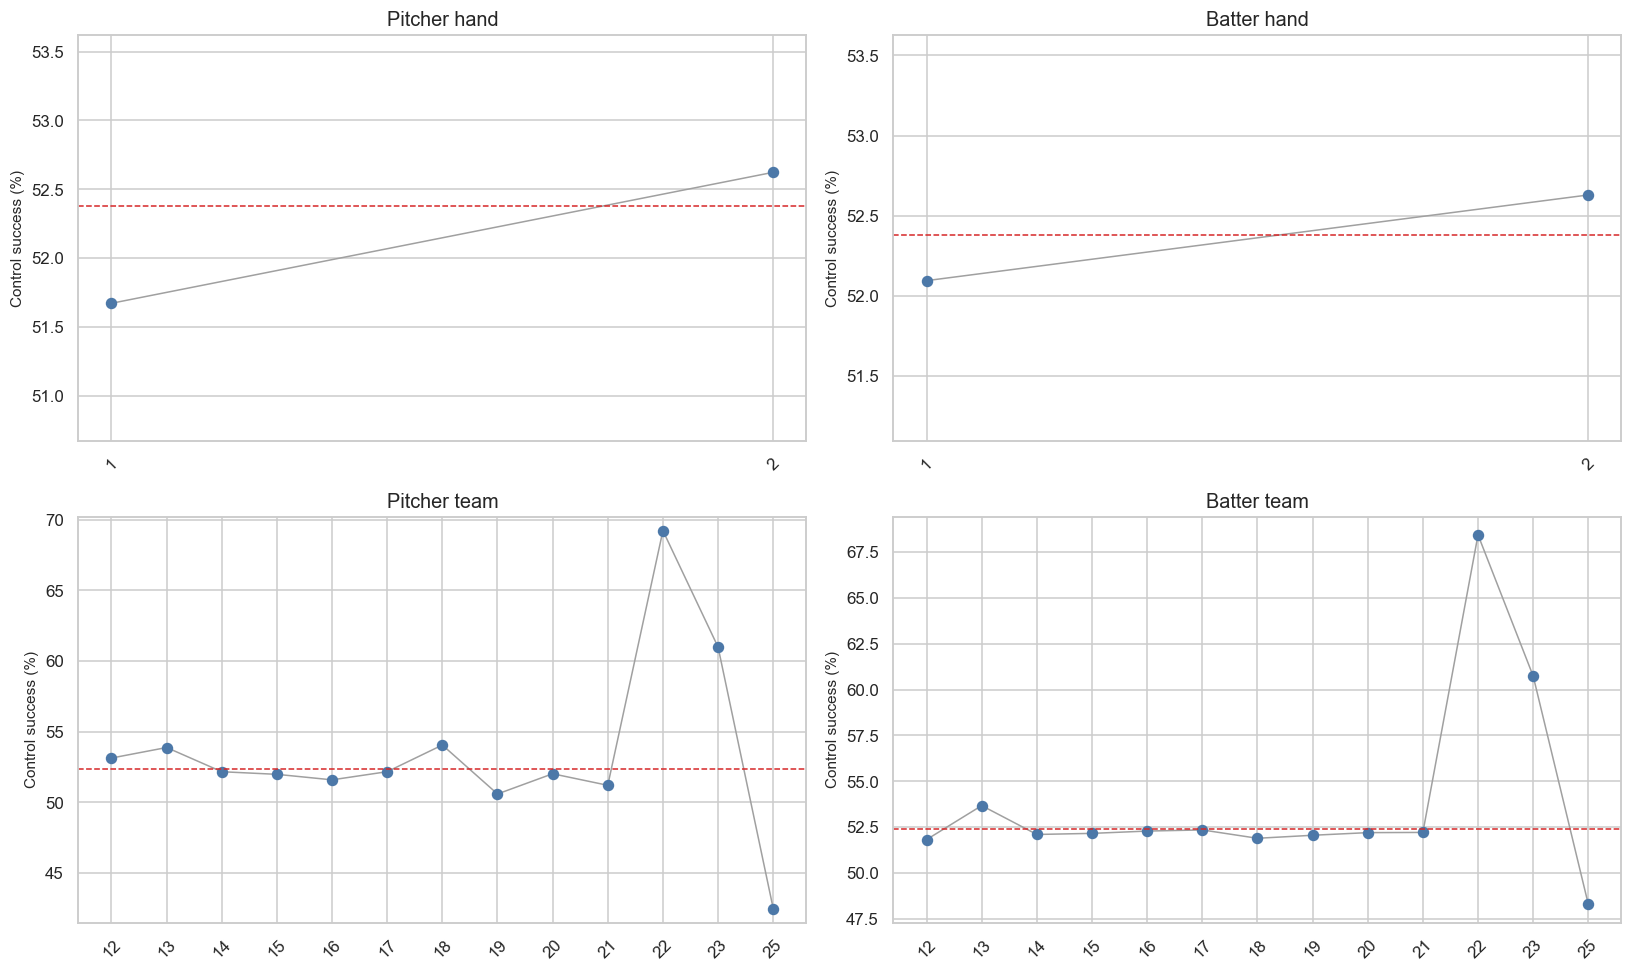


**결론:** 투수·타자 손 유형은 각각 단독으로는 성공률 차이가 1%p보다 작아 맞대결 조합으로 확인한다. 팀 ID는 전체 범위가 크게 보이지만 양끝 팀의 표본이 작으므로 팀 번호 자체를 안정적인 능력으로 해석하지 않는다.


In [6]:
for feature in standalone_features[6:]:
    print(f"[{feature}] {standalone_labels[feature]}")
    display(standalone_value_summary.loc[standalone_value_summary["피처"].eq(feature)].rename(columns={"n": "투구 수"}))
display(standalone_spread.loc[standalone_spread["피처"].isin(standalone_features[6:])])

fig, axes = plt.subplots(2, 2, figsize=(15, 9))
for ax, feature, title in zip(axes.flat, standalone_features[6:], ['Pitcher hand', 'Batter hand', 'Pitcher team', 'Batter team']):
    plot_standalone(ax, feature, title)
fig.tight_layout()
fig.savefig(EDA_ASSET_DIR / 'group1_standalone_hands_teams.svg', bbox_inches='tight')
plt.show()


display(Markdown(f"""
**결론:** 투수·타자 손 유형은 각각 단독으로는 성공률 차이가 1%p보다 작아 맞대결 조합으로 확인한다. 팀 ID는 전체 범위가 크게 보이지만 양끝 팀의 표본이 작으므로 팀 번호 자체를 안정적인 능력으로 해석하지 않는다.
"""))


### 0.3 선수 ID 2개

각 점을 선수 ID 하나로 두고, ID별 투구 수와 성공률의 관계를 확인한다. 가로축은 ID 번호가 아니라 해당 선수의 투구 수다.


,구분,전체 ID 수,ID당 투구 수 중앙값,100구 미만 ID 수,200구 이상 ID 수,200구 이상 ID 성공률 하위 10%(%),중앙값(%),상위 10%(%)
0,투수,792,856.5000,143,577,45.6589,52.1138,59.2850
1,타자,830,473.0000,229,507,48.9467,52.6754,60.6908


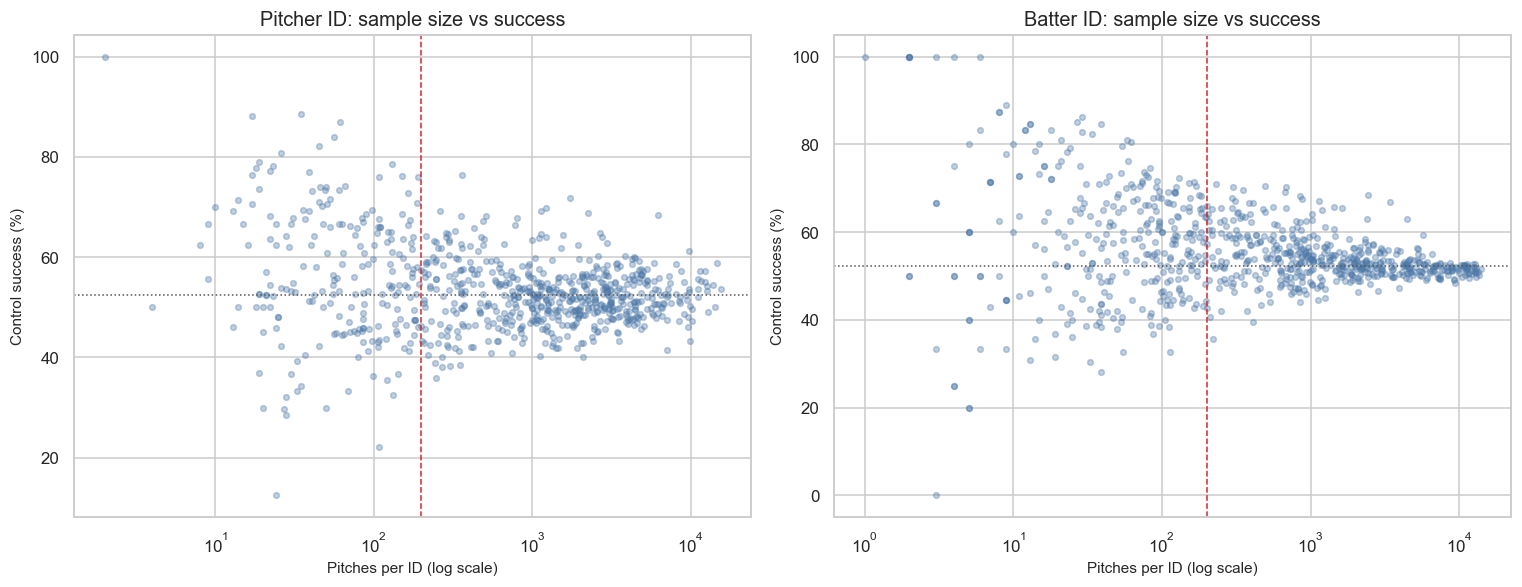


**결론:** 표본이 적은 ID에서 성공률이 넓게 흔들린다. 선수별 차이는 존재하지만 ID만 사용하면 소표본 선수와 새 선수에 취약하므로 과거 표본 수·누적 성공률·시즌과 함께 검증한다.


In [7]:
player_id_rows = []
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for ax, (entity, entity_en, id_col, stats_frame) in zip(axes, [('투수', 'Pitcher', 'pitcher_id', pitcher_stats), ('타자', 'Batter', 'batter_id', batter_stats)]):
    reliable = stats_frame.loc[stats_frame['n'].ge(200)].copy()
    q = reliable['success_rate'].quantile([.1, .5, .9]) * 100
    player_id_rows.append({
        '구분': entity, '전체 ID 수': len(stats_frame), 'ID당 투구 수 중앙값': stats_frame['n'].median(),
        '100구 미만 ID 수': int(stats_frame['n'].lt(100).sum()), '200구 이상 ID 수': len(reliable),
        '200구 이상 ID 성공률 하위 10%(%)': q.loc[.1], '중앙값(%)': q.loc[.5], '상위 10%(%)': q.loc[.9],
    })
    ax.scatter(stats_frame['n'], stats_frame['success_rate'] * 100, s=14, alpha=.35, color='#4C78A8', rasterized=True)
    ax.axvline(200, color='#D62728', linestyle='--', linewidth=1)
    ax.axhline(overall_rate * 100, color='#555555', linestyle=':', linewidth=1)
    ax.set_xscale('log')
    ax.set_title(f'{entity_en} ID: sample size vs success')
    ax.set_xlabel('Pitches per ID (log scale)')
    ax.set_ylabel('Control success (%)')
player_id_summary = pd.DataFrame(player_id_rows)
display(player_id_summary)
fig.tight_layout()
fig.savefig(EDA_ASSET_DIR / 'group1_standalone_player_ids.svg', bbox_inches='tight')
plt.show()


display(Markdown("""
**결론:** 표본이 적은 ID에서 성공률이 넓게 흔들린다. 선수별 차이는 존재하지만 ID만 사용하면 소표본 선수와 새 선수에 취약하므로 과거 표본 수·누적 성공률·시즌과 함께 검증한다.
"""))


## 1. 시즌에 따른 변화

시즌별 기준 성공률이 얼마나 달라졌는지 확인하고, 경기 유형과 월의 관계가 여러 시즌에서 반복되는지 분리해 본다.


### 1.1 시즌별 투구 수와 제구 성공률

**목적:** 시즌별 표본 수 차이와 성공률 변화를 구분한다.

**방법:** 시즌별 투구 수·성공률·95% 신뢰구간을 계산한다.


,시즌,투구 수,제구 성공 투구 수,제구 성공률(%),95% 신뢰구간 하한(%),95% 신뢰구간 상한(%),그룹 1 원본 변수 결측률(%)
0,2019,237413,134060,56.4670,56.2675,56.6663,0.0000
1,2020,244087,130028,53.2712,53.0732,53.4691,0.0000
2,2021,247088,131639,53.2762,53.0794,53.4728,0.0000
3,2022,247472,130893,52.8920,52.6953,53.0887,0.0000
4,2023,245525,122752,49.9957,49.7979,50.1935,0.0000
5,2024,253507,123231,48.6105,48.4160,48.8051,0.0000


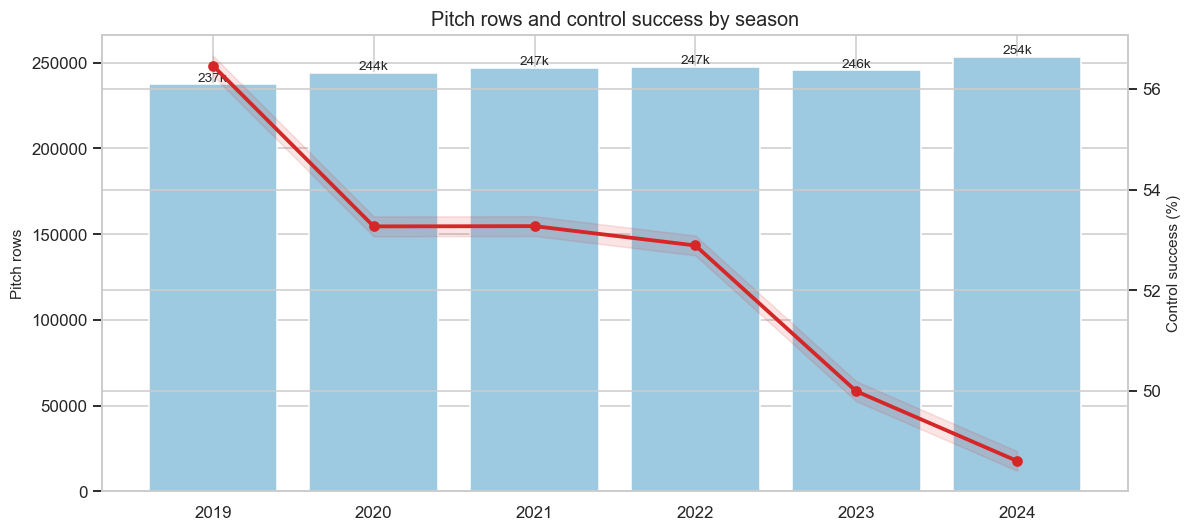

2019 → 2024 성공률 변화: -7.8565%p


In [8]:
season_summary = aggregate_rate(df, "season")
group1_missing_by_season = pd.Series({
    season: part[GROUP1].isna().to_numpy().mean() * 100
    for season, part in df.groupby("season", observed=True)
}, name="group1_missing_pct")
season_summary = season_summary.merge(group1_missing_by_season.rename_axis("season").reset_index(), on="season")
season_summary_display = readable_rate_table(season_summary, {"season": "시즌"}).rename(
    columns={"group1_missing_pct": "그룹 1 원본 변수 결측률(%)"}
)
display(season_summary_display)

fig, ax1 = plt.subplots(figsize=(11, 5))
bars = ax1.bar(season_summary["season"], season_summary["n"], color="#9ecae1", label="Pitch rows")
ax1.set_ylabel("Pitch rows")
ax1.ticklabel_format(style="plain", axis="y")
ax2 = ax1.twinx()
ax2.plot(season_summary["season"], season_summary["success_rate"] * 100,
         marker="o", linewidth=2.5, color="#d62728", label="Success rate")
ax2.fill_between(season_summary["season"], season_summary["ci_low"]*100,
                 season_summary["ci_high"]*100, color="#d62728", alpha=.12)
ax2.set_ylabel("Control success (%)")
ax1.set_title("Pitch rows and control success by season")
for bar in bars:
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height(), f"{bar.get_height()/1000:.0f}k",
             ha="center", va="bottom", fontsize=9)
fig.tight_layout()
fig.savefig(EDA_ASSET_DIR / "group1_season_rows_success.svg", bbox_inches="tight")
plt.show()

first_row, last_row = season_summary.iloc[0], season_summary.iloc[-1]
season_drop_pp = (last_row["success_rate"] - first_row["success_rate"]) * 100
print(f"{int(first_row.season)} → {int(last_row.season)} 성공률 변화: {season_drop_pp:+.4f}%p")

**출력 해설 — 시즌별 표본량과 성공률**

- **표 읽는 법:** `n`은 시즌별 행 수, `successes`는 성공 건수, `success_rate`는 성공률이다. `ci_low`와 `ci_high`는 성공률의 95% 신뢰구간이며, 마지막 열은 그룹 1 원본 변수의 결측률이다.
- **그래프 읽는 법:** 막대는 시즌별 행 수, 빨간 선은 성공률, 선 주변의 옅은 영역은 95% 신뢰구간이다. 두 축의 단위가 다르므로 막대 높이와 선 높이를 직접 비교하지 않는다.
- **이번 결과:** 행 수는 시즌마다 약 23.7만–25.4만 행으로 비슷하지만 성공률은 2019년 56.47%에서 2024년 48.61%로 7.86%p 하락했다.
- **의미:** 표본량 감소가 성공률 하락을 설명하기보다는 시즌에 따라 타깃 기준선 자체가 달라졌음을 보여준다. 모델 평가는 무작위 분할보다 과거 시즌 학습 → 미래 시즌 검증이 중요하다.
- **주의:** 시즌과 성공률의 관계는 관찰 결과이며, 시즌 자체가 원인이라는 뜻은 아니다.


### 1.2 경기 유형은 시즌별로 비교

**목적:** `game_type`의 전체 평균 차이가 시즌마다 같은 방향인지 확인한다.

**방법:** 시즌별 F/R 투구 수와 성공률을 비교한다. 공식 설명서에는 F/R의 풀네임이 없으므로 코드 이름을 유지한다.


,시즌,경기 유형 코드,투구 수,제구 성공 투구 수,제구 성공률(%),95% 신뢰구간 하한(%),95% 신뢰구간 상한(%)
0,2019,F,25786,17773,68.9250,68.3573,69.4870
1,2019,R,211627,116287,54.9490,54.7370,55.1609
2,2020,F,23213,13644,58.7774,58.1428,59.4091
3,2020,R,220874,116384,52.6925,52.4842,52.9007
4,2021,F,25861,18202,70.3840,69.8245,70.9374
5,2021,R,221227,113437,51.2763,51.0680,51.4846
6,2022,F,30448,21580,70.8749,70.3620,71.3826
7,2022,R,217024,109313,50.3691,50.1587,50.5794
8,2023,F,25686,12147,47.2904,46.6802,47.9013
9,2023,R,219839,110605,50.3118,50.1028,50.5208


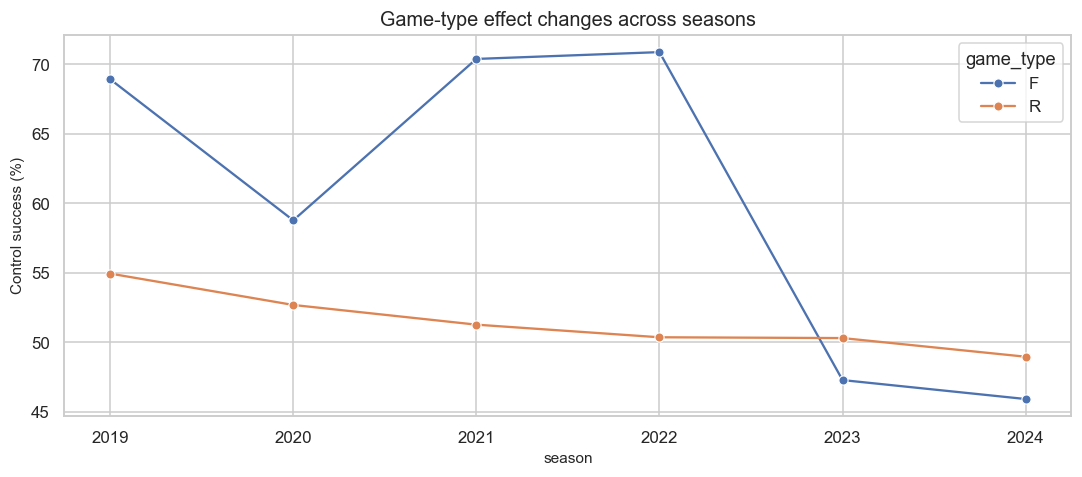

,F-R 성공률 차이(%p)
시즌,
2019,13.9760
2020,6.0849
2021,19.1077
2022,20.5059
2023,-3.0215
2024,-3.0427



**결론:** F-R 성공률 차이는 2019~2022년에는 양수지만 2023~2024년에는 음수로 바뀐다. `game_type`에 고정된 효과를 부여하기보다 `season × game_type`으로 검증한다. F는 3~10월에 관측되고 전체 F 투구의 3~8월 비중이 **82.68%**이므로 포스트시즌 코드는 아니다. 공식 설명서에는 F/R의 풀네임이 없으므로 코드 이름은 그대로 유지한다.


In [9]:
game_type_summary = aggregate_rate(df, ["season", "game_type"])
display(readable_rate_table(game_type_summary, {"season": "시즌", "game_type": "경기 유형 코드"}))
plt.figure(figsize=(10, 4.5))
sns.lineplot(data=game_type_summary, x="season", y=game_type_summary["success_rate"]*100,
             hue="game_type", marker="o")
plt.ylabel("Control success (%)")
plt.title("Game-type effect changes across seasons")
plt.tight_layout()
plt.savefig(EDA_ASSET_DIR / "group1_season_game_type.svg", bbox_inches="tight")
plt.show()

game_type_pivot = game_type_summary.pivot(index="season", columns="game_type", values="success_rate")
game_type_gap = (game_type_pivot["F"] - game_type_pivot["R"]) * 100
f_month_rows = df.loc[df["game_type"].astype(str).eq("F")].groupby("game_month", observed=True).size()
display(pd.DataFrame({"F-R 성공률 차이(%p)": game_type_gap}).rename_axis("시즌"))
display(Markdown(f"""
**결론:** F-R 성공률 차이는 2019~2022년에는 양수지만 2023~2024년에는 음수로 바뀐다. `game_type`에 고정된 효과를 부여하기보다 `season × game_type`으로 검증한다. F는 3~10월에 관측되고 전체 F 투구의 3~8월 비중이 **{f_month_rows.loc[3:8].sum()/f_month_rows.sum():.2%}**이므로 포스트시즌 코드는 아니다. 공식 설명서에는 F/R의 풀네임이 없으므로 코드 이름은 그대로 유지한다.
"""))


### 1.3 시즌 × 월 heatmap

**목적:** 특정 월의 성공률이 높거나 낮은 관계가 여러 시즌에서 반복되는지 확인한다.

**방법:** 시즌×월 성공률 heatmap과 같은 위치의 투구 수 heatmap을 함께 비교한다.


,season,최고 성공률 월,최저 성공률 월,시즌 내 월 차이(%p),월 순서와 성공률 Spearman
0,2019,10,8,4.6697,-0.2857
1,2020,5,10,1.7090,-0.6571
2,2021,7,10,6.5822,-0.7857
3,2022,5,10,4.7760,-0.8929
4,2023,10,4,2.3324,0.7857
5,2024,10,9,2.9422,-0.3095


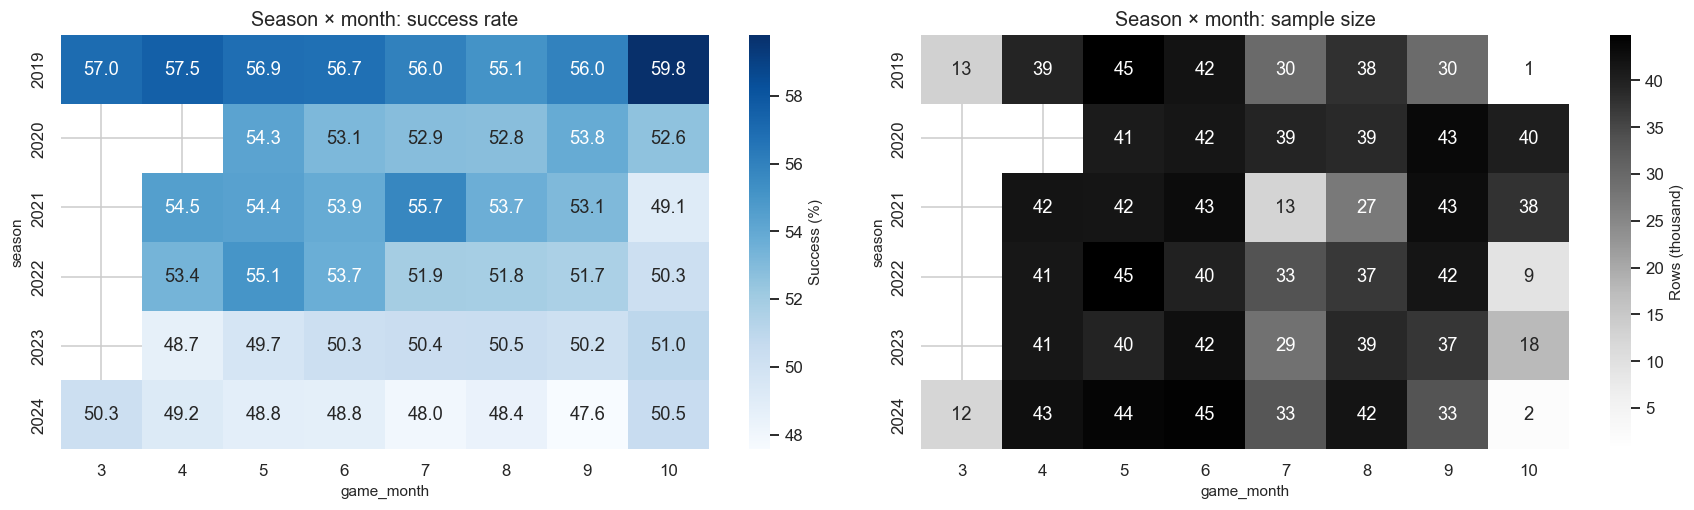


**결론:** 모든 시즌에 반복되는 뚜렷한 월별 패턴은 확인되지 않는다. 10월은 2019·2023·2024년에는 시즌 내 최고 성공률이지만 2020·2021·2022년에는 최저 성공률이다. 월 순서와 성공률의 상관 방향도 2023년만 양수이고 나머지 시즌은 음수다. 따라서 `game_month`는 독립적인 계절 효과로 보기 어렵고, `season`과 함께 쓰거나 단독 추가 성능이 있는지만 확인한다.


In [10]:
season_month_rate = df.pivot_table(index="season", columns="game_month", values=TARGET,
                                         aggfunc="mean", observed=True) * 100
season_month_count = df.pivot_table(index="season", columns="game_month", values=TARGET,
                                          aggfunc="size", observed=True)

season_month_pattern = pd.DataFrame({
    '최고 성공률 월': season_month_rate.idxmax(axis=1),
    '최저 성공률 월': season_month_rate.idxmin(axis=1),
    '시즌 내 월 차이(%p)': season_month_rate.max(axis=1) - season_month_rate.min(axis=1),
    '월 순서와 성공률 Spearman': season_month_rate.apply(
        lambda row: pd.Series(row.dropna().index, index=row.dropna().index).corr(row.dropna(), method='spearman'),
        axis=1,
    ),
}).reset_index()
display(season_month_pattern)

fig, axes = plt.subplots(1, 2, figsize=(16, 4.8))
sns.heatmap(season_month_rate, annot=True, fmt=".1f", cmap="Blues", ax=axes[0],
            cbar_kws={"label": "Success (%)"})
axes[0].set_title("Season × month: success rate")
sns.heatmap(season_month_count/1000, annot=True, fmt=".0f", cmap="Greys", ax=axes[1],
            cbar_kws={"label": "Rows (thousand)"})
axes[1].set_title("Season × month: sample size")
plt.tight_layout()
fig.savefig(EDA_ASSET_DIR / "group1_season_month_heatmap.svg", bbox_inches="tight")
plt.show()

display(Markdown('''
**결론:** 모든 시즌에 반복되는 뚜렷한 월별 패턴은 확인되지 않는다. 10월은 2019·2023·2024년에는 시즌 내 최고 성공률이지만 2020·2021·2022년에는 최저 성공률이다. 월 순서와 성공률의 상관 방향도 2023년만 양수이고 나머지 시즌은 음수다. 따라서 `game_month`는 독립적인 계절 효과로 보기 어렵고, `season`과 함께 쓰거나 단독 추가 성능이 있는지만 확인한다.
'''))


## 2. 이닝과 경기 상황

이닝 자체의 관계와 LI·점수차·주자 상태가 함께 만드는 조건부 관계를 구분한다. LI는 투구 직전 상황이 경기 흐름에 미치는 중요도이며, 높은 LI가 반드시 낮은 제구 성공률을 뜻하지는 않는다.


### 2.1 이닝 구간별 성공률

**목적:** LI 수준이 달라도 후반 이닝의 성공률이 낮은지 확인한다.

**방법:** 1–3회, 4–6회, 7–9회, 연장으로 나누고 각 구간의 LI 25·50·75% 분위수 경계를 기준으로 Q1~Q4를 만든다. 같은 LI 값이 경계에 몰리면 각 집단의 투구 수는 정확히 25%가 아닐 수 있다. Q1→Q4는 시간 흐름이 아니라 같은 이닝 구간 안의 서로 다른 투구 집단이다.


,이닝 구간,투구 수,제구 성공 투구 수,제구 성공률(%),95% 신뢰구간 하한(%),95% 신뢰구간 상한(%)
0,1-3,498766,264823,53.0956,52.9571,53.2341
1,4-6,494934,259775,52.4868,52.3476,52.6259
2,7-9,461440,237932,51.5629,51.4187,51.7071
3,Extra,19952,10073,50.4862,49.7924,51.1798


[해석 기준] 이닝 구간 내부 상대 LI 구간의 실제 경계


,LI 최솟값,하위 25% 경계,중앙값,상위 25% 시작 경계,LI 최댓값
이닝 구간,,,,,
1-3,0.0100,0.6200,0.8700,1.2200,3.5200
4-6,0.0000,0.4100,0.8000,1.2700,5.0800
7-9,0.0000,0.0900,0.5000,1.4800,10.8300
Extra,0.0000,1.8000,2.3200,3.2700,10.8300


,이닝 구간,투구 수,LI 평균,하위 10% 경계,하위 25% 경계,LI 중앙값,상위 25% 시작 경계,상위 10% 시작 경계,LI 최댓값
0,1-3,498766,0.9675,0.4000,0.6200,0.8700,1.2200,1.6800,3.5200
1,4-6,494934,0.9345,0.1500,0.4100,0.8000,1.2700,1.8800,5.0800
2,7-9,461440,0.9810,0.0100,0.0900,0.5000,1.4800,2.6300,10.8300
3,Extra,19952,2.5355,0.9100,1.8000,2.3200,3.2700,4.6200,10.8300


,이닝 구간,같은 이닝 구간 안에서의 LI 상대 위치,투구 수,제구 성공 투구 수,제구 성공률(%),95% 신뢰구간 하한(%),95% 신뢰구간 상한(%)
0,1-3,낮은 LI 구간(Q1),139723,73838,52.8460,52.5842,53.1077
1,1-3,중간 아래 LI 구간(Q2),123439,65135,52.7670,52.4884,53.0454
2,1-3,중간 위 LI 구간(Q3),111100,59672,53.7102,53.4168,54.0032
3,1-3,높은 LI 구간(Q4),124504,66178,53.1533,52.8760,53.4304
4,4-6,낮은 LI 구간(Q1),125677,65077,51.7812,51.5048,52.0574
5,4-6,중간 아래 LI 구간(Q2),123243,64742,52.5320,52.2531,52.8107
6,4-6,중간 위 LI 구간(Q3),124277,65535,52.7330,52.4554,53.0105
7,4-6,높은 LI 구간(Q4),121737,64421,52.9182,52.6377,53.1985
8,7-9,낮은 LI 구간(Q1),117180,59597,50.8594,50.5731,51.1456
9,7-9,중간 아래 LI 구간(Q2),116257,59723,51.3715,51.0842,51.6588


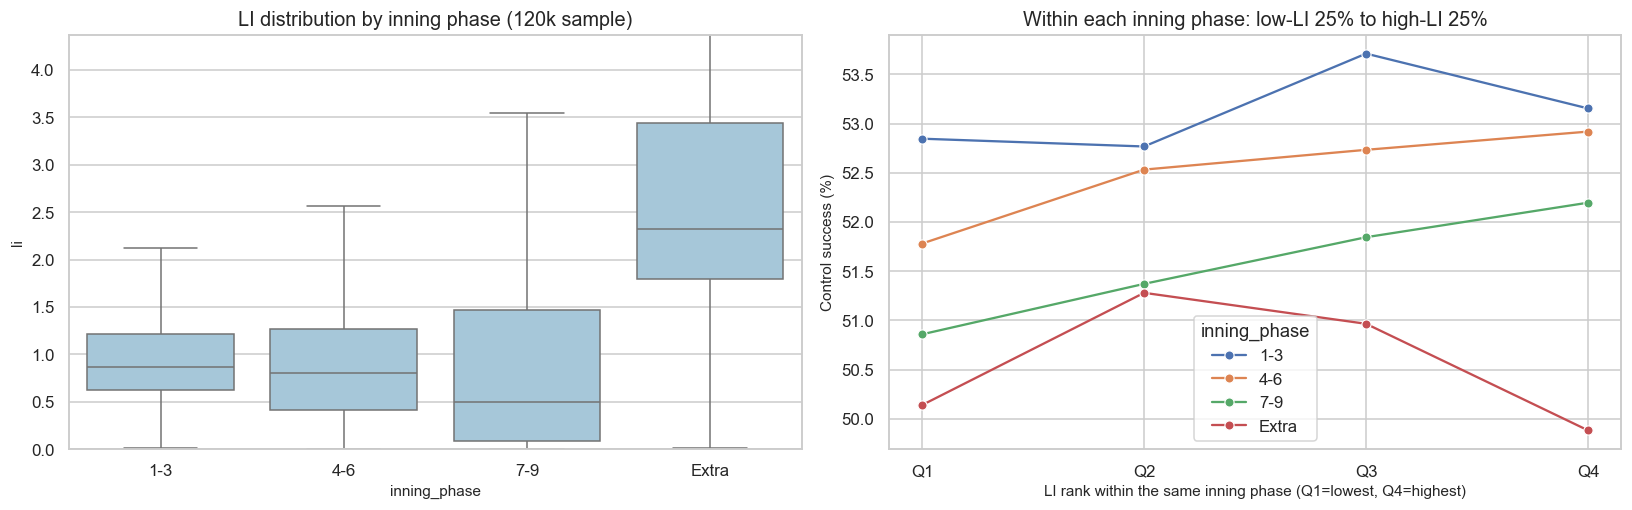

In [11]:
inning_phase_summary = aggregate_rate(df, "inning_phase")
display(readable_rate_table(inning_phase_summary, {"inning_phase": "이닝 구간"}))

li_within_phase_edges_df = pd.DataFrame(li_within_phase_edges).set_index("inning_phase")

print("[해석 기준] 이닝 구간 내부 상대 LI 구간의 실제 경계")
display(li_within_phase_edges_df.rename(columns={"LI_min": "LI 최솟값", "LI_q25": "하위 25% 경계", "LI_q50": "중앙값", "LI_q75": "상위 25% 시작 경계", "LI_max": "LI 최댓값"}).rename_axis("이닝 구간"))

li_distribution = df.groupby("inning_phase", observed=True)["li"].agg(
    n="size", mean="mean", q10=lambda s: s.quantile(.10), q25=lambda s: s.quantile(.25),
    q50="median", q75=lambda s: s.quantile(.75), q90=lambda s: s.quantile(.90), max="max"
).reset_index()
display(li_distribution.rename(columns={"inning_phase": "이닝 구간", "n": "투구 수", "mean": "LI 평균", "q10": "하위 10% 경계", "q25": "하위 25% 경계", "q50": "LI 중앙값", "q75": "상위 25% 시작 경계", "q90": "상위 10% 시작 경계", "max": "LI 최댓값"}))

inning_li_quantile_band = aggregate_rate(df.dropna(subset=["li_within_inning_quantile_band"]),
                                         ["inning_phase", "li_within_inning_quantile_band"])
li_band_display = readable_rate_table(inning_li_quantile_band, {
    "inning_phase": "이닝 구간",
    "li_within_inning_quantile_band": "같은 이닝 구간 안에서의 LI 상대 위치",
})
li_band_display["같은 이닝 구간 안에서의 LI 상대 위치"] = li_band_display[
    "같은 이닝 구간 안에서의 LI 상대 위치"
].replace({
    "Q1": "낮은 LI 구간(Q1)",
    "Q2": "중간 아래 LI 구간(Q2)",
    "Q3": "중간 위 LI 구간(Q3)",
    "Q4": "높은 LI 구간(Q4)",
})
display(li_band_display)

fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))
sns.boxplot(data=df.sample(120_000, random_state=42), x="inning_phase", y="li",
            showfliers=False, ax=axes[0], color="#9ecae1")
axes[0].set_title("LI distribution by inning phase (120k sample)")
axes[0].set_ylim(0, df["li"].quantile(.99))
sns.lineplot(data=inning_li_quantile_band, x="li_within_inning_quantile_band",
             y=inning_li_quantile_band["success_rate"]*100, hue="inning_phase", marker="o", ax=axes[1])
axes[1].set_title("Within each inning phase: low-LI 25% to high-LI 25%")
axes[1].set_xlabel("LI rank within the same inning phase (Q1=lowest, Q4=highest)")
axes[1].set_ylabel("Control success (%)")
plt.tight_layout()
plt.show()


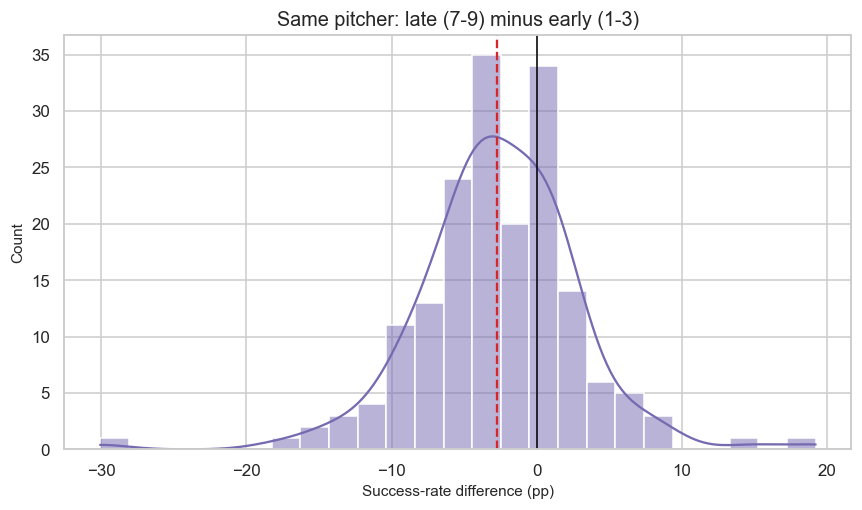

,값
1–3회와 7–9회에 각각 최소 200구가 있는 투수 수,178.0000
투수별 (7–9회 - 1–3회) 성공률 차이의 평균(%p),-2.6804
투수별 (7–9회 - 1–3회) 성공률 차이의 중앙값(%p),-2.7142
7–9회 성공률이 1–3회보다 낮은 투수 비율(%),68.5393



**결론:** 1–3회와 7–9회에 각각 200구 이상이 있는 동일 투수 **178명**에서도 후반-초반 성공률 차이는 평균 **-2.68%p**다. 투수 구성이 달라서 생긴 차이만으로 설명되지는 않지만, 이를 피로의 인과효과로 단정하지 않는다.


In [12]:
pitcher_phase = df[df["inning_phase"].isin(["1-3", "7-9"])].groupby(
    ["pitcher_id", "inning_phase"], observed=True
)[TARGET].agg(["size", "mean"]).reset_index()
eligible = pitcher_phase.pivot(index="pitcher_id", columns="inning_phase", values=["size", "mean"]).dropna()
eligible = eligible[(eligible[("size", "1-3")] >= 200) & (eligible[("size", "7-9")] >= 200)].copy()
eligible["late_minus_early_pp"] = (
    eligible[("mean", "7-9")] - eligible[("mean", "1-3")]
) * 100

fig, ax = plt.subplots(figsize=(8, 4.8))
sns.histplot(eligible["late_minus_early_pp"], bins=25, kde=True, ax=ax, color="#756bb1")
ax.axvline(0, color="black", linewidth=1)
ax.axvline(eligible["late_minus_early_pp"].median(), color="#d62728", linestyle="--")
ax.set_title("Same pitcher: late (7-9) minus early (1-3)")
ax.set_xlabel("Success-rate difference (pp)")
plt.tight_layout()
plt.show()

within_pitcher_summary = pd.Series({
    "eligible_pitchers_min_200_each": len(eligible),
    "mean_late_minus_early_pp": eligible["late_minus_early_pp"].mean(),
    "median_late_minus_early_pp": eligible["late_minus_early_pp"].median(),
    "share_negative_pct": eligible["late_minus_early_pp"].lt(0).mean()*100,
})
display(within_pitcher_summary.rename(index={
    "eligible_pitchers_min_200_each": "1–3회와 7–9회에 각각 최소 200구가 있는 투수 수",
    "mean_late_minus_early_pp": "투수별 (7–9회 - 1–3회) 성공률 차이의 평균(%p)",
    "median_late_minus_early_pp": "투수별 (7–9회 - 1–3회) 성공률 차이의 중앙값(%p)",
    "share_negative_pct": "7–9회 성공률이 1–3회보다 낮은 투수 비율(%)",
}).to_frame("값"))
display(Markdown(f"""
**결론:** 1–3회와 7–9회에 각각 200구 이상이 있는 동일 투수 **{len(eligible):,}명**에서도 후반-초반 성공률 차이는 평균 **{eligible['late_minus_early_pp'].mean():.2f}%p**다. 투수 구성이 달라서 생긴 차이만으로 설명되지는 않지만, 이를 피로의 인과효과로 단정하지 않는다.
"""))


### 2.2 이닝 × LI × 점수차 × 주자 상태

**목적:** 같은 이닝·LI에서도 점수차와 주자 상태에 따라 성공률이 달라지는지 확인한다.

**방법:** 이닝 구간, 상대 LI 4등분, 투수 팀 점수차 5구간, 주자 수와 베이스 점유 상태를 함께 집계한다. 모든 관측 조합을 표시하고 성공률과 투구 수를 같은 위치에서 비교한다.


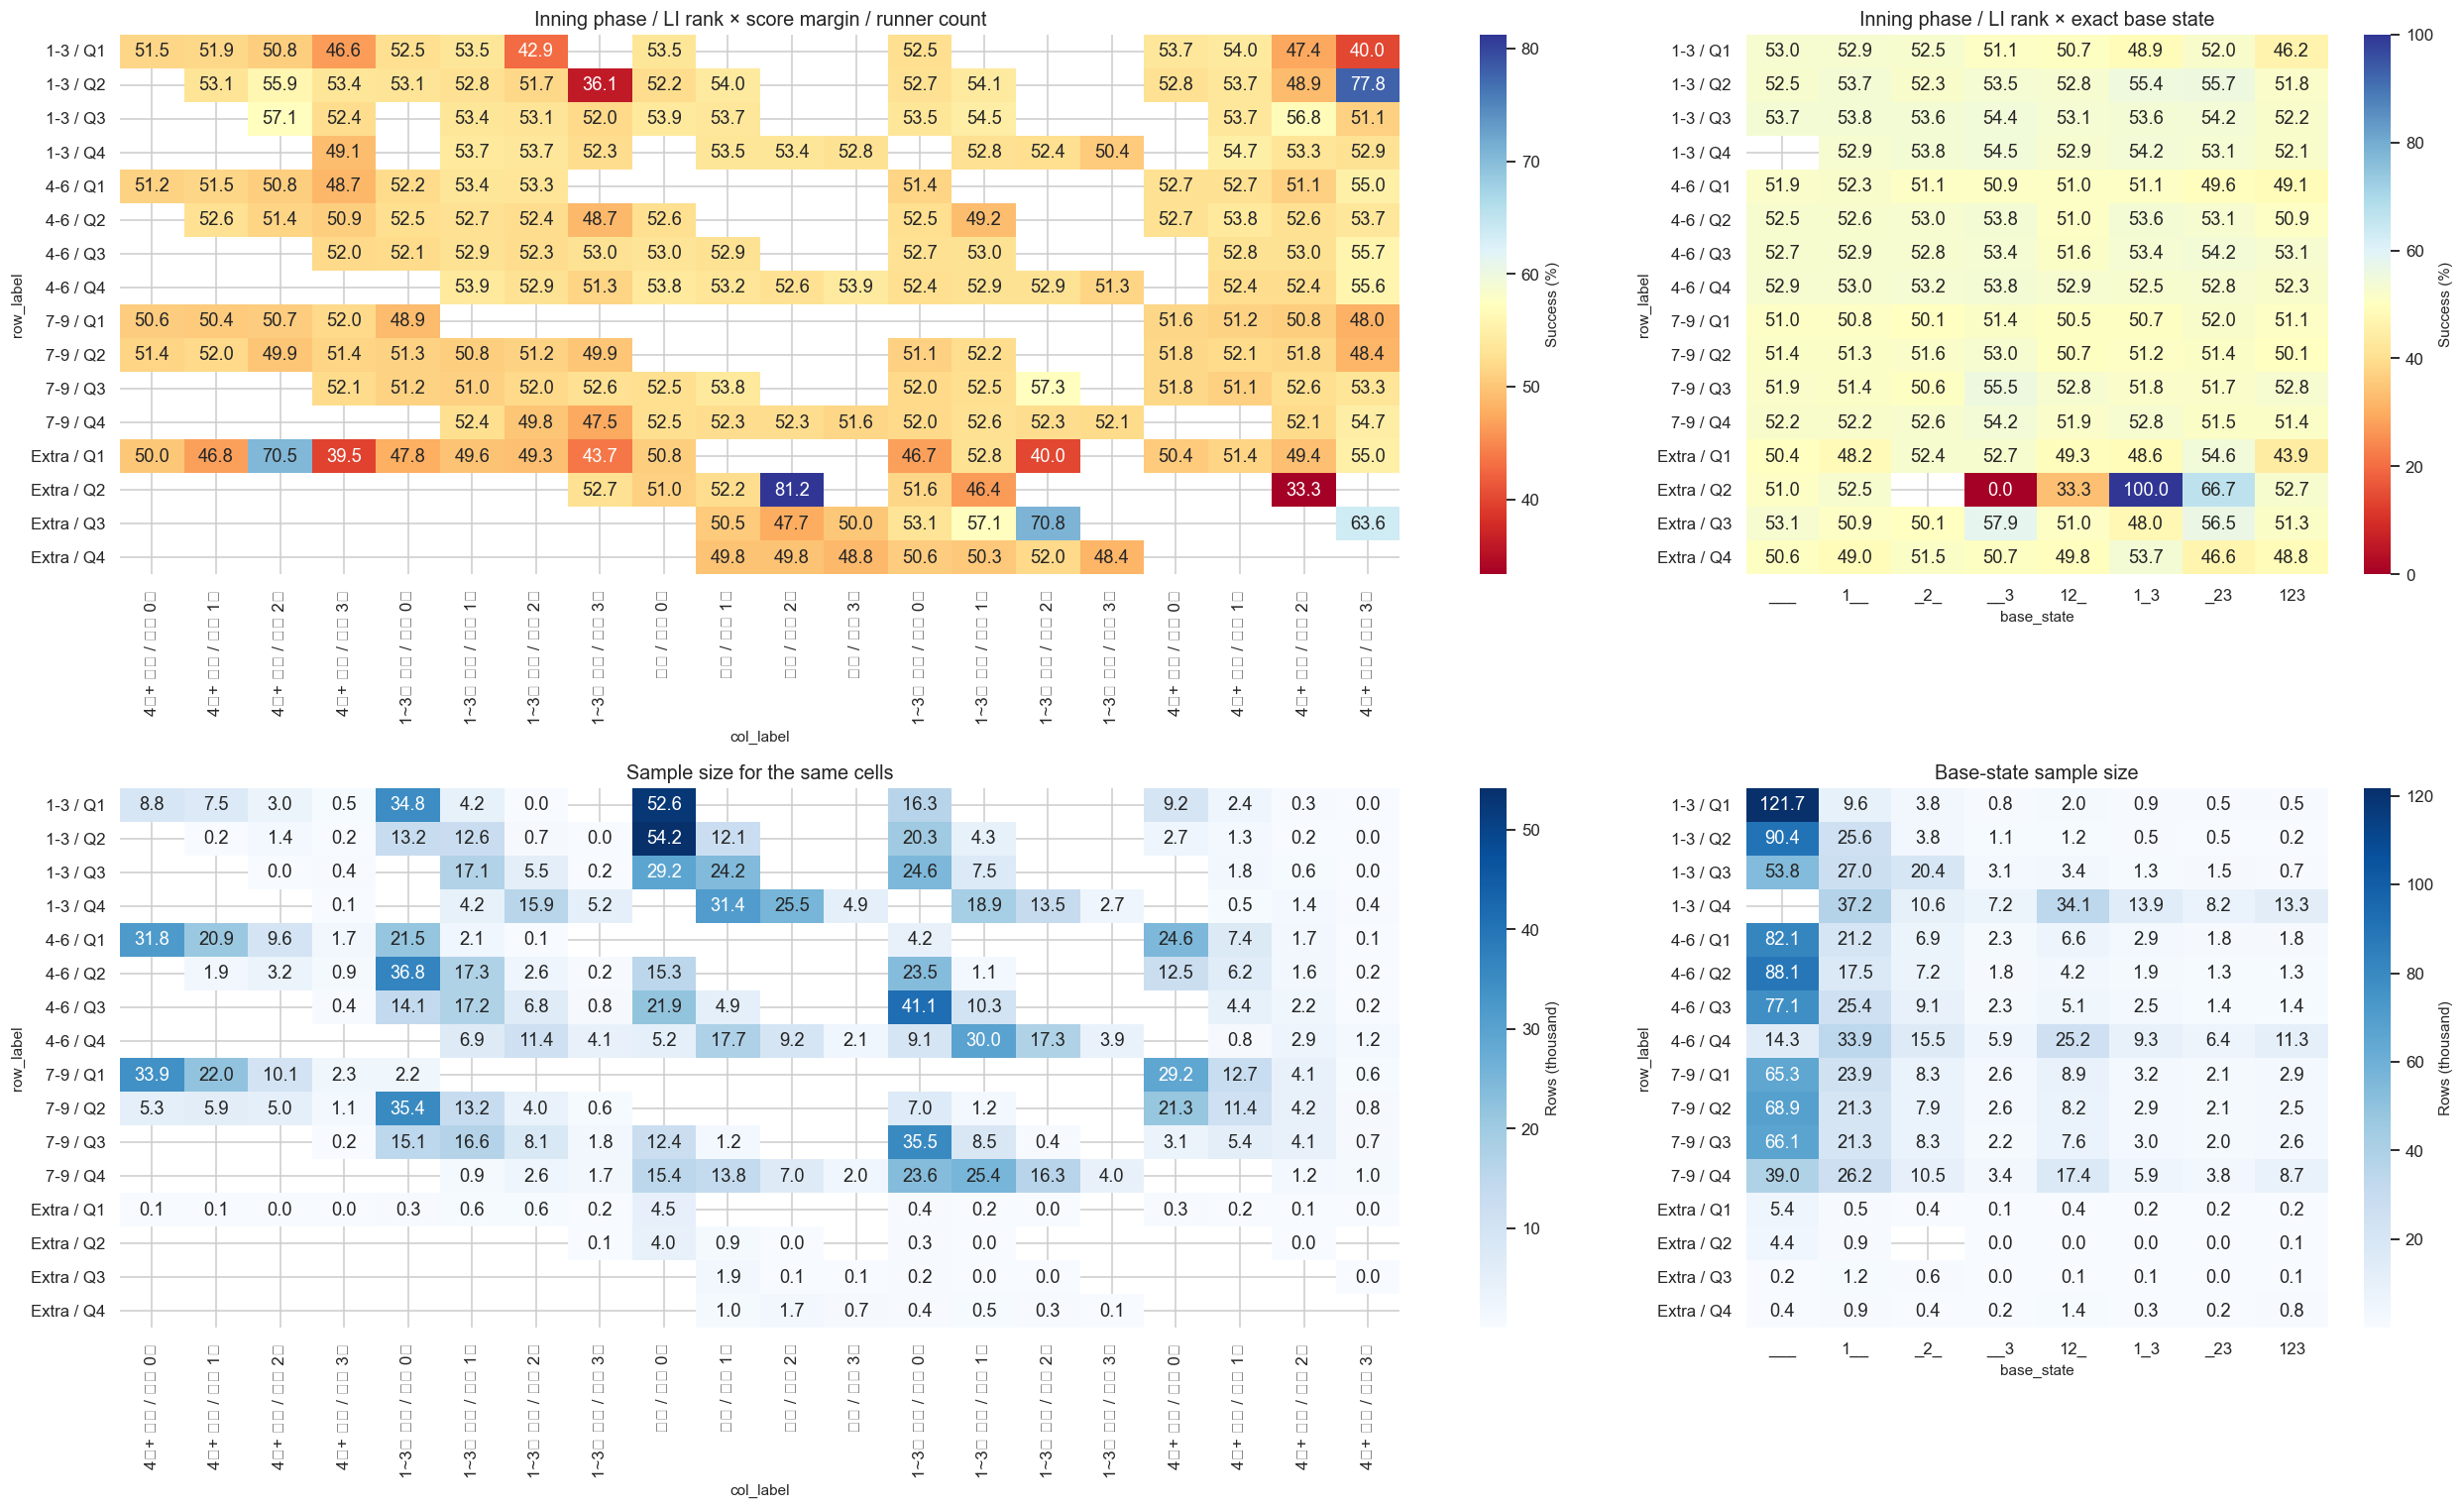

,이닝 구간,구간 내부 LI 위치,투수 팀 점수차,주자 수,투구 수,제구 성공 투구 수,제구 성공률(%),95% 신뢰구간 하한(%),95% 신뢰구간 상한(%)
177,Extra,Q2,4점+ 앞섬,2,6,2,33.3333,9.6769,70.0012
19,1-3,Q2,1~3점 뒤짐,3,36,13,36.1111,22.4754,52.4252
158,Extra,Q1,4점+ 뒤짐,3,43,17,39.5349,26.3651,54.4212
166,Extra,Q1,1~3점 앞섬,2,20,8,40.0000,21.8804,61.3422
12,1-3,Q1,4점+ 앞섬,3,25,10,40.0000,23.4031,59.2609
184,Extra,Q3,4점+ 앞섬,3,11,7,63.6364,35.3797,84.8338
157,Extra,Q1,4점+ 뒤짐,2,44,31,70.4545,55.7795,81.8446
183,Extra,Q3,1~3점 앞섬,2,24,17,70.8333,50.8319,85.0855
27,1-3,Q2,4점+ 앞섬,3,9,7,77.7778,45.2583,93.6776
174,Extra,Q2,동점,2,16,13,81.2500,56.9906,93.4085


,읽는 축,관찰된 패턴,피처 의미
0,이닝,"1~3회 52.77~53.71%, 7~9회 50.86~52.20%",LI 구간이 달라도 후반 이닝의 성공률이 낮아 이닝 순서 정보가 남는다.
1,LI,"4~6회 Q1→Q4 51.78→52.92%, 7~9회 50.86→52.20%",높은 LI가 제구를 일관되게 낮춘다는 단순 관계는 없다.
2,점수차,"4점 이상 뒤짐 51.04%, 동점 53.01%",점수차는 경기 상황 구성의 차이를 담지만 선형 효과로 단정할 수 없다.
3,주자 수,"주자 없음 52.30%, 1명 52.60%, 만루 51.61%",만루 평균은 낮지만 세부 셀의 방향은 섞여 있어 조건 정보로 사용한다.



**결론:** heatmap에서 가장 일관된 신호는 **LI 구간이 달라도 1~3회보다 7~9회의 성공률이 낮다**는 점이다. 반면 높은 LI가 성공률을 낮추는 패턴은 없으며, 4~6회와 7~9회에서는 Q4가 Q1보다 각각 **1.14%p**, **1.34%p** 높다. 4점 이상 뒤짐과 만루의 전체 평균은 낮지만 세부 셀에서는 방향이 섞인다. 따라서 `inning`은 순서형 핵심 피처로 유지하고, `li × 점수차 × 주자 상태`는 고정 규칙이 아니라 조건부 상호작용 후보로만 검증한다. 전체 조합 범위 **33.33%~81.25%**의 양끝은 각각 **6구**, **16구**이므로 효과 크기로 해석하지 않는다.


In [13]:
score_diff_labels = ["4점+ 뒤짐", "1~3점 뒤짐", "동점", "1~3점 앞섬", "4점+ 앞섬"]
df["score_diff_pitcher_bin"] = pd.cut(
    df["score_diff_pitcher_team"],
    bins=[-np.inf, -4, -1, 0, 3, np.inf],
    labels=score_diff_labels,
    ordered=True,
)
context_cube = aggregate_rate(
    df.dropna(subset=["li_within_inning_quantile_band"]),
    ["inning_phase", "li_within_inning_quantile_band", "score_diff_pitcher_bin", "num_runners_on"],
)
context_cube["row_label"] = (
    context_cube["inning_phase"].astype(str) + " / " +
    context_cube["li_within_inning_quantile_band"].astype(str)
)
context_cube["col_label"] = (
    context_cube["score_diff_pitcher_bin"].astype(str) + " / 주자 " +
    context_cube["num_runners_on"].astype(int).astype(str) + "명"
)
row_order = [f"{phase} / Q{q}" for phase in inning_labels for q in range(1, 5)]
col_order = [f"{score} / 주자 {r}명" for score in score_diff_labels for r in range(4)]
context_rate = context_cube.pivot(index="row_label", columns="col_label", values="success_rate").reindex(index=row_order, columns=col_order) * 100
context_n = context_cube.pivot(index="row_label", columns="col_label", values="n").reindex(index=row_order, columns=col_order)

base_context = aggregate_rate(
    df.dropna(subset=["li_within_inning_quantile_band"]),
    ["inning_phase", "li_within_inning_quantile_band", "base_state"],
)
base_context["row_label"] = base_context["inning_phase"].astype(str) + " / " + base_context["li_within_inning_quantile_band"].astype(str)
base_order = ["___", "1__", "_2_", "__3", "12_", "1_3", "_23", "123"]
base_rate = base_context.pivot(index="row_label", columns="base_state", values="success_rate").reindex(index=row_order, columns=base_order) * 100
base_n = base_context.pivot(index="row_label", columns="base_state", values="n").reindex(index=row_order, columns=base_order)

fig, axes = plt.subplots(2, 2, figsize=(23, 14), gridspec_kw={"width_ratios": [2.2, 1]})
sns.heatmap(context_rate, annot=True, fmt=".1f", cmap="RdYlBu", ax=axes[0, 0], cbar_kws={"label": "Success (%)"})
axes[0, 0].set_title("Inning phase / LI rank × score margin / runner count")
sns.heatmap(context_n / 1000, annot=True, fmt=".1f", cmap="Blues", ax=axes[1, 0], cbar_kws={"label": "Rows (thousand)"})
axes[1, 0].set_title("Sample size for the same cells")
sns.heatmap(base_rate, annot=True, fmt=".1f", cmap="RdYlBu", ax=axes[0, 1], cbar_kws={"label": "Success (%)"})
axes[0, 1].set_title("Inning phase / LI rank × exact base state")
sns.heatmap(base_n / 1000, annot=True, fmt=".1f", cmap="Blues", ax=axes[1, 1], cbar_kws={"label": "Rows (thousand)"})
axes[1, 1].set_title("Base-state sample size")
fig.tight_layout()
fig.savefig(EDA_ASSET_DIR / "group1_ext_inning_li_score_runners.svg", bbox_inches="tight")
plt.show()

observed_cells = context_cube.sort_values("success_rate")
context_extremes = pd.concat([observed_cells.head(5), observed_cells.tail(5)]).copy()
display(readable_rate_table(context_extremes[[
    "inning_phase", "li_within_inning_quantile_band", "score_diff_pitcher_bin", "num_runners_on",
    "n", "successes", "success_rate", "ci_low", "ci_high"
]], {
    "inning_phase": "이닝 구간", "li_within_inning_quantile_band": "구간 내부 LI 위치",
    "score_diff_pitcher_bin": "투수 팀 점수차", "num_runners_on": "주자 수",
}))

phase_li_readout = aggregate_rate(
    df.dropna(subset=["li_within_inning_quantile_band"]),
    ["inning_phase", "li_within_inning_quantile_band"],
).pivot(index="inning_phase", columns="li_within_inning_quantile_band", values="success_rate") * 100
score_readout = aggregate_rate(df, "score_diff_pitcher_bin").set_index("score_diff_pitcher_bin")
runner_readout = aggregate_rate(df, "num_runners_on").set_index("num_runners_on")
context_key_readout = pd.DataFrame([
    {
        "읽는 축": "이닝",
        "관찰된 패턴": f"1~3회 {phase_li_readout.loc['1-3'].min():.2f}~{phase_li_readout.loc['1-3'].max():.2f}%, 7~9회 {phase_li_readout.loc['7-9'].min():.2f}~{phase_li_readout.loc['7-9'].max():.2f}%",
        "피처 의미": "LI 구간이 달라도 후반 이닝의 성공률이 낮아 이닝 순서 정보가 남는다.",
    },
    {
        "읽는 축": "LI",
        "관찰된 패턴": f"4~6회 Q1→Q4 {phase_li_readout.loc['4-6', 'Q1']:.2f}→{phase_li_readout.loc['4-6', 'Q4']:.2f}%, 7~9회 {phase_li_readout.loc['7-9', 'Q1']:.2f}→{phase_li_readout.loc['7-9', 'Q4']:.2f}%",
        "피처 의미": "높은 LI가 제구를 일관되게 낮춘다는 단순 관계는 없다.",
    },
    {
        "읽는 축": "점수차",
        "관찰된 패턴": f"4점 이상 뒤짐 {score_readout.loc['4점+ 뒤짐', 'success_rate']:.2%}, 동점 {score_readout.loc['동점', 'success_rate']:.2%}",
        "피처 의미": "점수차는 경기 상황 구성의 차이를 담지만 선형 효과로 단정할 수 없다.",
    },
    {
        "읽는 축": "주자 수",
        "관찰된 패턴": f"주자 없음 {runner_readout.loc[0, 'success_rate']:.2%}, 1명 {runner_readout.loc[1, 'success_rate']:.2%}, 만루 {runner_readout.loc[3, 'success_rate']:.2%}",
        "피처 의미": "만루 평균은 낮지만 세부 셀의 방향은 섞여 있어 조건 정보로 사용한다.",
    },
])
display(context_key_readout)
display(Markdown(f"""
**결론:** heatmap에서 가장 일관된 신호는 **LI 구간이 달라도 1~3회보다 7~9회의 성공률이 낮다**는 점이다. 반면 높은 LI가 성공률을 낮추는 패턴은 없으며, 4~6회와 7~9회에서는 Q4가 Q1보다 각각 **{phase_li_readout.loc['4-6', 'Q4']-phase_li_readout.loc['4-6', 'Q1']:.2f}%p**, **{phase_li_readout.loc['7-9', 'Q4']-phase_li_readout.loc['7-9', 'Q1']:.2f}%p** 높다. 4점 이상 뒤짐과 만루의 전체 평균은 낮지만 세부 셀에서는 방향이 섞인다. 따라서 `inning`은 순서형 핵심 피처로 유지하고, `li × 점수차 × 주자 상태`는 고정 규칙이 아니라 조건부 상호작용 후보로만 검증한다. 전체 조합 범위 **{observed_cells['success_rate'].min():.2%}~{observed_cells['success_rate'].max():.2%}**의 양끝은 각각 **{int(observed_cells.iloc[0]['n']):,}구**, **{int(observed_cells.iloc[-1]['n']):,}구**이므로 효과 크기로 해석하지 않는다.
"""))

## 3. 투수·타자 손 유형과 과거 구종 구성

손 유형을 각각 보는 것보다 맞대결 조합으로 볼 때 차이가 커지는지, 투수의 투구 직전 과거 구종 구성과 결합할 가치가 있는지 확인한다.


### 3.1 투수 손 유형 × 타자 손 유형

**목적:** 네 손 유형 맞대결 조합의 성공률 차이를 확인한다.

**방법:** 코드 1/2를 실제 좌·우로 임의 해석하지 않고 네 조합의 투구 수와 성공률을 비교한다.


,투수 손 유형 × 타자 손 유형,투구 수,제구 성공 투구 수,제구 성공률(%),95% 신뢰구간 하한(%),95% 신뢰구간 상한(%)
0,1-1,170292,83601,49.0927,48.8553,49.3302
1,1-2,211059,113445,53.7504,53.5376,53.9630
2,2-1,525455,278841,53.0666,52.9316,53.2015
3,2-2,568286,296716,52.2124,52.0826,52.3423


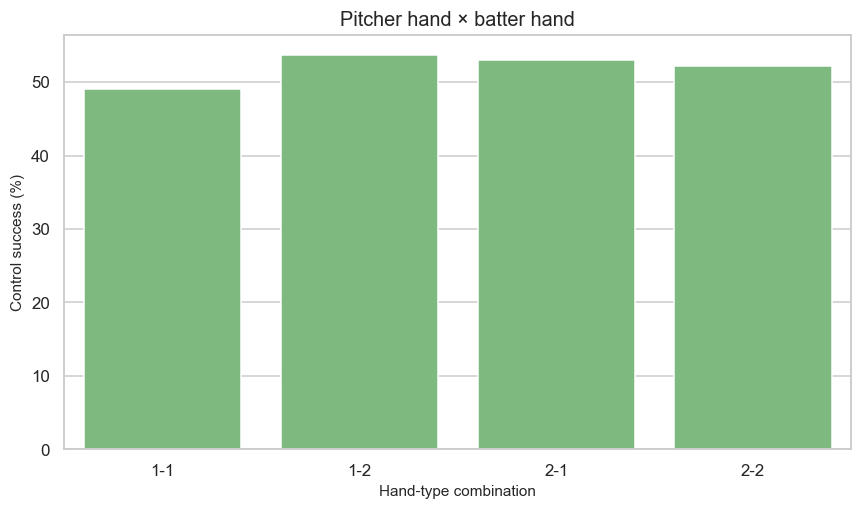


**결론:** 네 손 유형 조합의 성공률은 **49.09%~53.75%**로 **4.66%p** 차이다. 두 손 유형을 각각 쓰는 것보다 조합 또는 상호작용으로 검증할 근거가 있다. 코드 1/2를 실제 좌·우로 임의 변환하지 않는다.


In [14]:
hand_summary = aggregate_rate(df, "hand_matchup")
display(readable_rate_table(hand_summary, {"hand_matchup": "투수 손 유형 × 타자 손 유형"}))

fig, ax = plt.subplots(figsize=(8, 4.8))
sns.barplot(data=hand_summary, x="hand_matchup", y=hand_summary["success_rate"]*100, ax=ax, color="#74c476")
ax.set_title("Pitcher hand × batter hand")
ax.set_ylabel("Control success (%)")
ax.set_xlabel("Hand-type combination")
plt.tight_layout()
plt.show()

hand_min = hand_summary.loc[hand_summary["success_rate"].idxmin()]
hand_max = hand_summary.loc[hand_summary["success_rate"].idxmax()]
display(Markdown(f"""
**결론:** 네 손 유형 조합의 성공률은 **{hand_min.success_rate:.2%}~{hand_max.success_rate:.2%}**로 **{(hand_max.success_rate-hand_min.success_rate)*100:.2f}%p** 차이다. 두 손 유형을 각각 쓰는 것보다 조합 또는 상호작용으로 검증할 근거가 있다. 코드 1/2를 실제 좌·우로 임의 변환하지 않는다.
"""))


### 3.2 손 유형 조합 × 투수의 과거 구종군 비율

**목적:** 같은 손 유형 조합에서도 투수의 평소 구종 구성에 따라 성공률 관계가 달라지는지 확인한다.

**방법:** 투구 직전까지 계산된 fastball·breaking·offspeed 비율을 각각 네 상대 구간으로 나누고 모든 손 유형 조합을 표시한다. 현재 투구의 실제 구종은 사용하지 않는다.


,q0,q25,q50,q75,q100
구종군 비율,,,,,
Fastball,0.0000,0.4865,0.5440,0.6136,1.0000
Breaking,0.0000,0.2159,0.2893,0.3618,1.0000
Offspeed,0.0000,0.0750,0.1406,0.2170,1.0000


,과거 구종군 비율,투수·타자 손 유형 조합,구종군 비율 상대 구간,해당 구간의 평균 비율,투구 수,제구 성공 투구 수,제구 성공률(%),95% 신뢰구간 하한(%),95% 신뢰구간 상한(%)
0,Fastball,1-1,Q1 낮음,0.4352,48374,24027,49.6692,49.2237,50.1148
1,Fastball,1-1,Q2,0.5124,34220,16750,48.9480,48.4185,49.4777
2,Fastball,1-1,Q3,0.5799,41619,20138,48.3866,47.9066,48.8668
3,Fastball,1-1,Q4 높음,0.6836,45958,22626,49.2319,48.7749,49.6890
4,Fastball,1-2,Q1 낮음,0.4378,58715,31881,54.2979,53.8947,54.7005
5,Fastball,1-2,Q2,0.5129,43823,23596,53.8439,53.3768,54.3103
6,Fastball,1-2,Q3,0.5804,54136,29019,53.6039,53.1835,54.0237
7,Fastball,1-2,Q4 높음,0.6822,54303,28908,53.2346,52.8147,53.6541
8,Fastball,2-1,Q1 낮음,0.4404,127795,67925,53.1515,52.8778,53.4250
9,Fastball,2-1,Q2,0.5150,139994,73260,52.3308,52.0691,52.5924


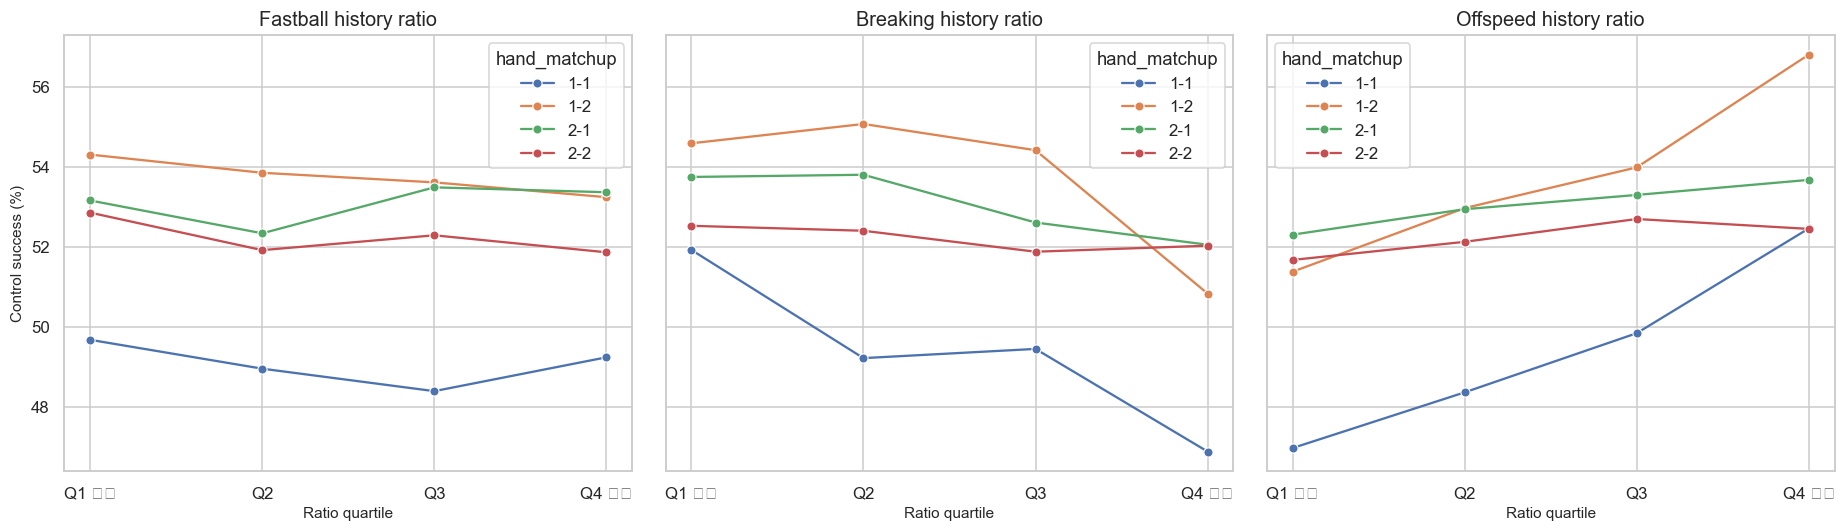


**결론:** 관측된 모든 손 유형 조합과 과거 구종군 비율 구간의 성공률은 **46.88%~56.80%**다. 현재 투구의 구종 효과가 아니라, 투구 직전까지의 평소 구종 구성과 손 유형 조합이 함께 나타낸 관찰 차이로 해석한다. 표의 투구 수를 함께 보고 시간 순서 검증에서 상호작용의 추가 성능을 확인한다.


In [15]:
pitchmix_rate_cols = {
    "Fastball": "asof_pitcher_fastball_rate",
    "Breaking": "asof_pitcher_breaking_rate",
    "Offspeed": "asof_pitcher_offspeed_rate",
}
pitchmix_rows = []
pitchmix_edges = []
for mix_name, rate_col in pitchmix_rate_cols.items():
    valid = df.dropna(subset=[rate_col]).copy()
    valid["mix_level"] = pd.qcut(valid[rate_col], 4, labels=["Q1 낮음", "Q2", "Q3", "Q4 높음"], duplicates="drop")
    edges = valid[rate_col].quantile([0, .25, .5, .75, 1])
    pitchmix_edges.append({"구종군 비율": mix_name, **{f"q{int(q*100)}": v for q, v in edges.items()}})
    summary = aggregate_rate(valid, ["hand_matchup", "mix_level"])
    summary["pitchmix"] = mix_name
    summary["rate_mean"] = valid.groupby(["hand_matchup", "mix_level"], observed=True)[rate_col].mean().to_numpy()
    pitchmix_rows.append(summary)

hand_pitchmix = pd.concat(pitchmix_rows, ignore_index=True)
display(pd.DataFrame(pitchmix_edges).set_index("구종군 비율"))
display(readable_rate_table(
    hand_pitchmix[["pitchmix", "hand_matchup", "mix_level", "rate_mean", "n", "successes", "success_rate", "ci_low", "ci_high"]],
    {"pitchmix": "과거 구종군 비율", "hand_matchup": "투수·타자 손 유형 조합", "mix_level": "구종군 비율 상대 구간", "rate_mean": "해당 구간의 평균 비율"},
))

fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharey=True)
for ax, mix_name in zip(axes, pitchmix_rate_cols):
    plot_data = hand_pitchmix.loc[hand_pitchmix["pitchmix"].eq(mix_name)].copy()
    plot_data["success_pct"] = plot_data["success_rate"] * 100
    sns.lineplot(data=plot_data, x="mix_level", y="success_pct", hue="hand_matchup", marker="o", ax=ax)
    ax.set_title(f"{mix_name} history ratio")
    ax.set_xlabel("Ratio quartile")
    ax.set_ylabel("Control success (%)")
fig.tight_layout()
fig.savefig(EDA_ASSET_DIR / "group1_ext_hand_pitchmix.svg", bbox_inches="tight")
plt.show()



display(Markdown(f"""
**결론:** 관측된 모든 손 유형 조합과 과거 구종군 비율 구간의 성공률은 **{hand_pitchmix['success_rate'].min():.2%}~{hand_pitchmix['success_rate'].max():.2%}**다. 현재 투구의 구종 효과가 아니라, 투구 직전까지의 평소 구종 구성과 손 유형 조합이 함께 나타낸 관찰 차이로 해석한다. 표의 투구 수를 함께 보고 시간 순서 검증에서 상호작용의 추가 성능을 확인한다.
"""))


## 4. 선수 ID와 과거 기록

ID별 성공률 차이가 표본 수 부족에 얼마나 민감한지, 새 선수와 기존 선수의 과거 기록량이 얼마나 다른지 확인한다.


### 4.1 선수별 표본 불균형

0.3절의 산점도에서 소표본 ID일수록 성공률이 넓게 흔들렸다. 여기서는 매 시즌 데이터에 처음 등장한 선수와 그 선수와 관련된 투구 비중을 확인한다.

#### 시즌별 신규 투수의 투구 비율·신규 타자의 상대 투구 비율


[투수 기준] 해당 시즌에 데이터에서 처음 관측된 투수가 던진 모든 투구를 집계


,시즌,시즌 내 전체 투수 수,해당 시즌에 처음 관측된 투수 수,그 투수들이 던진 투구 수,시즌 투구 중 그 투수들의 비중(%),그 투수들이 던진 투구의 제구 성공률(%),이전 시즌부터 관측된 투수의 제구 성공률(%)
0,2019,355,355,237413,100.0000,56.4670,NaN
1,2020,356,110,54621,22.3777,54.2191,52.9979
2,2021,386,95,50819,20.5672,52.8818,53.3783
3,2022,390,88,38950,15.7392,54.3877,52.6127
4,2023,382,63,33878,13.7982,49.8642,50.0168
5,2024,391,81,50348,19.8606,48.9930,48.5157


[타자 기준] 해당 시즌에 데이터에서 처음 관측된 타자가 상대한 모든 투구를 집계


,시즌,시즌 내 전체 타자 수,해당 시즌에 처음 관측된 타자 수,그 타자들이 상대한 투구 수,시즌 투구 중 그 타자들이 상대한 비중(%),그 타자들이 상대한 투구의 제구 성공률(%),이전 시즌부터 관측된 타자가 상대한 투구의 제구 성공률(%)
0,2019,400,400,237413,100.0000,56.4670,NaN
1,2020,371,95,28318,11.6016,54.1387,53.1573
2,2021,398,88,21683,8.7754,56.9340,52.9243
3,2022,403,88,27278,11.0227,55.3303,52.5900
4,2023,397,71,23091,9.4047,49.3612,50.0616
5,2024,424,88,23588,9.3047,47.3588,48.7389


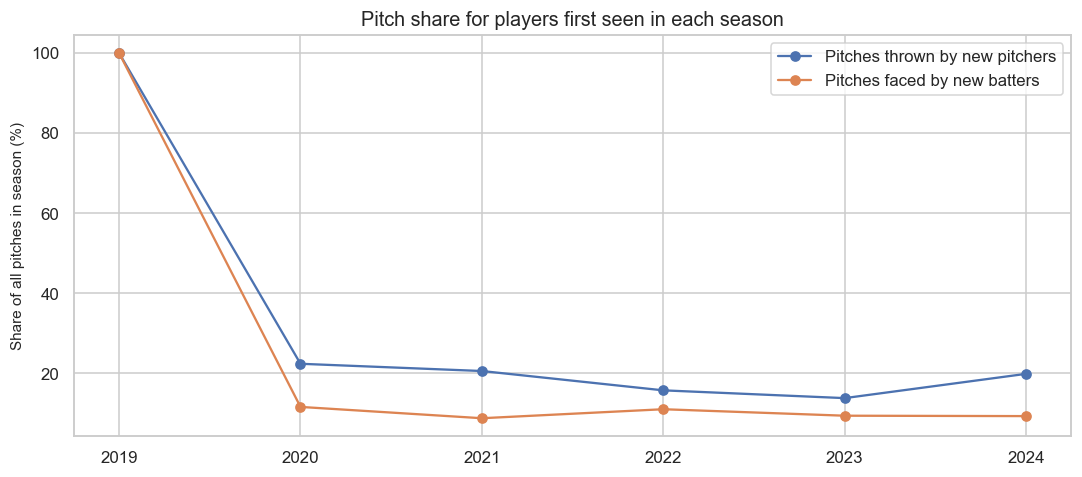

2019는 관측 시작점이므로 모든 ID가 데이터에서 처음 관측된 것으로 표시됩니다. 실질적인 비교는 2020년 이후입니다.


In [16]:
first_observed_rows = []
for season, part in df.groupby("season", observed=True):
    first_observed_rows.append({
        "season": season,
        "pitcher_ids_in_season": part["pitcher_id"].nunique(),
        "first_seen_pitcher_ids": part.loc[part["pitcher_first_seen_in_season"], "pitcher_id"].nunique(),
        "first_seen_pitcher_pitch_rows": int(part["pitcher_first_seen_in_season"].sum()),
        "first_seen_pitcher_pitch_row_pct": part["pitcher_first_seen_in_season"].mean()*100,
        "first_seen_pitcher_pitch_success_pct": part.loc[part["pitcher_first_seen_in_season"], TARGET].mean()*100,
        "previously_seen_pitcher_pitch_success_pct": part.loc[~part["pitcher_first_seen_in_season"], TARGET].mean()*100,
        "batter_ids_in_season": part["batter_id"].nunique(),
        "first_seen_batter_ids": part.loc[part["batter_first_seen_in_season"], "batter_id"].nunique(),
        "first_seen_batter_pitch_rows": int(part["batter_first_seen_in_season"].sum()),
        "first_seen_batter_pitch_row_pct": part["batter_first_seen_in_season"].mean()*100,
        "first_seen_batter_pitch_success_pct": part.loc[part["batter_first_seen_in_season"], TARGET].mean()*100,
        "previously_seen_batter_pitch_success_pct": part.loc[~part["batter_first_seen_in_season"], TARGET].mean()*100,
    })
first_observed_summary = pd.DataFrame(first_observed_rows)
print("[투수 기준] 해당 시즌에 데이터에서 처음 관측된 투수가 던진 모든 투구를 집계")
display(first_observed_summary[[
    "season", "pitcher_ids_in_season", "first_seen_pitcher_ids",
    "first_seen_pitcher_pitch_rows", "first_seen_pitcher_pitch_row_pct",
    "first_seen_pitcher_pitch_success_pct", "previously_seen_pitcher_pitch_success_pct",
]].rename(columns={
    "season": "시즌",
    "pitcher_ids_in_season": "시즌 내 전체 투수 수",
    "first_seen_pitcher_ids": "해당 시즌에 처음 관측된 투수 수",
    "first_seen_pitcher_pitch_rows": "그 투수들이 던진 투구 수",
    "first_seen_pitcher_pitch_row_pct": "시즌 투구 중 그 투수들의 비중(%)",
    "first_seen_pitcher_pitch_success_pct": "그 투수들이 던진 투구의 제구 성공률(%)",
    "previously_seen_pitcher_pitch_success_pct": "이전 시즌부터 관측된 투수의 제구 성공률(%)",
}))

print("[타자 기준] 해당 시즌에 데이터에서 처음 관측된 타자가 상대한 모든 투구를 집계")
display(first_observed_summary[[
    "season", "batter_ids_in_season", "first_seen_batter_ids",
    "first_seen_batter_pitch_rows", "first_seen_batter_pitch_row_pct",
    "first_seen_batter_pitch_success_pct", "previously_seen_batter_pitch_success_pct",
]].rename(columns={
    "season": "시즌",
    "batter_ids_in_season": "시즌 내 전체 타자 수",
    "first_seen_batter_ids": "해당 시즌에 처음 관측된 타자 수",
    "first_seen_batter_pitch_rows": "그 타자들이 상대한 투구 수",
    "first_seen_batter_pitch_row_pct": "시즌 투구 중 그 타자들이 상대한 비중(%)",
    "first_seen_batter_pitch_success_pct": "그 타자들이 상대한 투구의 제구 성공률(%)",
    "previously_seen_batter_pitch_success_pct": "이전 시즌부터 관측된 타자가 상대한 투구의 제구 성공률(%)",
}))

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(first_observed_summary["season"], first_observed_summary["first_seen_pitcher_pitch_row_pct"], marker="o", label="Pitches thrown by new pitchers")
ax.plot(first_observed_summary["season"], first_observed_summary["first_seen_batter_pitch_row_pct"], marker="o", label="Pitches faced by new batters")
ax.set_ylabel("Share of all pitches in season (%)")
ax.set_title("Pitch share for players first seen in each season")
ax.legend()
plt.tight_layout()
fig.savefig(EDA_ASSET_DIR / "group1_first_observed_id_exposure.svg", bbox_inches="tight")
plt.show()

print("2019는 관측 시작점이므로 모든 ID가 데이터에서 처음 관측된 것으로 표시됩니다. 실질적인 비교는 2020년 이후입니다.")

**출력 해설 — 시즌별로 처음 관측된 선수의 투구 비중**

- **표 읽는 법:** 각 시즌의 전체 선수 수, 그 시즌에 학습 데이터에서 처음 관측된 선수 수, 해당 선수가 투수 또는 타자로 등장한 투구 수·비중, 기존 선수와의 성공률을 함께 보여준다.
- **그래프 읽는 법:** 선의 높이는 ‘처음 관측된 선수 수’가 아니라, 투수 기준으로는 그 투수들이 던진 투구의 비율이고 타자 기준으로는 그 타자들이 상대한 투구의 비율이다.
- **이번 결과:** 2020–2024년 해당 시즌에 처음 관측된 투수들이 던진 투구의 비중은 13.80–22.38%, 타자는 8.78–11.60%다. 2024년은 투수 19.86%, 타자 9.30%로 무시하기 어려운 규모다.
- **의미:** 미래 시즌에는 과거 기록이 부족하거나 학습 때 보지 못한 ID가 꾸준히 생긴다. ID만 외우는 모델보다 과거 표본 수와 대체값 처리에 견고한 모델이 필요하다.
- **주의:** 2019년은 데이터의 시작점이라 모든 선수가 ‘최초 관측’으로 표시된다. 또한 최초 관측은 실제 데뷔가 아니라 제공된 학습 데이터에서 처음 보였다는 뜻이며, 이들의 성공률이 항상 기존 선수보다 낮은 것도 아니다.


### 4.2 2024년 3월 신규·기존 투수 비교

2024년 3월 전체의 `asof_pitcher_n` 중앙값만 보면 기존 투수의 많은 과거 기록 때문에 기록 부족 문제가 가려질 수 있다. 제공된 학습 데이터에서 **2024년에 처음 관측된 투수**와 이전 시즌에도 관측된 투수를 분리해 과거 투구 수와 성공률을 비교한다.

> 여기서 첫 관측은 실제 리그 데뷔가 아니라 2019~2024년 제공 데이터에서 처음 보였다는 뜻이다.


,pitcher_history_group,투구_수,투수_수,과거_투구_수_중앙값,과거_투구_수_하위25pct,과거_투구_수_상위25pct_시작,제구_성공률_pct
0,2024년에 처음 관측된 투수,2242,21,58.0000,28.0000,106.0000,50.9367
1,이전 시즌에도 관측된 투수,10119,142,"3,814.0000","2,169.5000","6,907.5000",50.1136


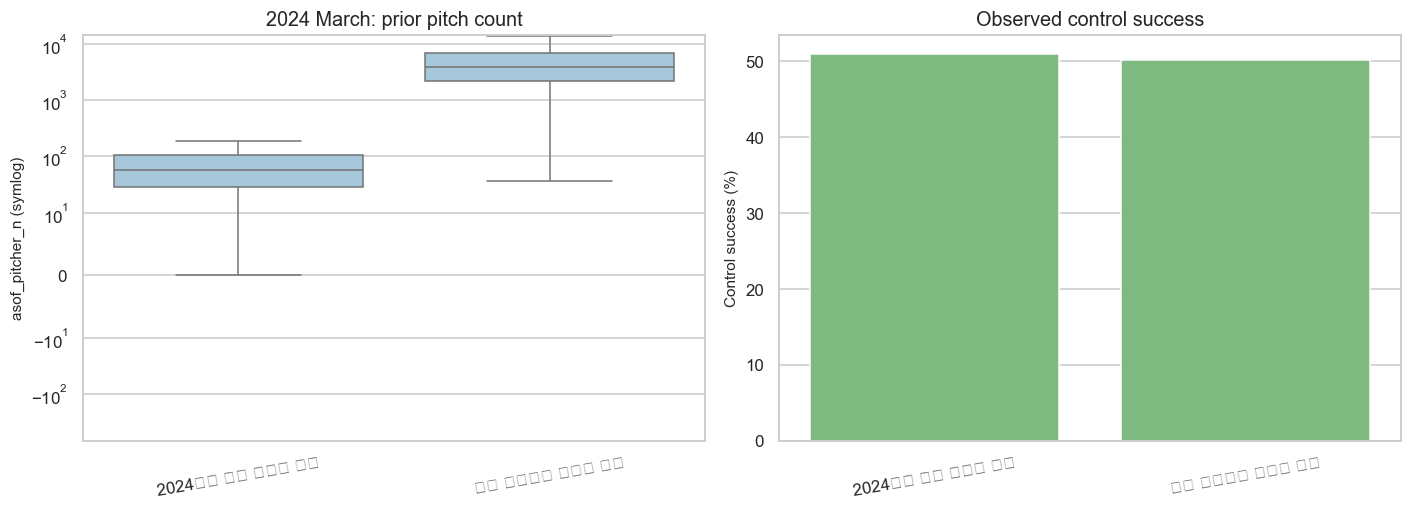


**결론:** 2024년 3월 전체 `asof_pitcher_n` 중앙값은 **2,900**이지만, 처음 관측된 투수는 **21명·2,242구**이고 중앙값이 **58구**뿐이다. 이전 시즌에도 관측된 투수의 중앙값 **3,814구**와 차이가 크다. 따라서 시즌 초 전체를 기록 부족으로 처리하지 않고, 선수별 과거 표본 수와 최초 관측 여부를 함께 사용한다.


In [17]:
march_2024 = df.loc[df["season"].eq(2024) & df["game_month"].eq(3)].copy()
march_2024["pitcher_history_group"] = np.where(
    march_2024["pitcher_first_seen_in_season"],
    "2024년에 처음 관측된 투수",
    "이전 시즌에도 관측된 투수",
)

march_pitcher_history = march_2024.groupby("pitcher_history_group", observed=True).agg(
    투구_수=(TARGET, "size"),
    투수_수=("pitcher_id", "nunique"),
    과거_투구_수_중앙값=("asof_pitcher_n", "median"),
    과거_투구_수_하위25pct=("asof_pitcher_n", lambda s: s.quantile(.25)),
    과거_투구_수_상위25pct_시작=("asof_pitcher_n", lambda s: s.quantile(.75)),
    제구_성공률=(TARGET, "mean"),
).reset_index()
march_pitcher_history["제구_성공률_pct"] = march_pitcher_history["제구_성공률"] * 100
display(march_pitcher_history.drop(columns="제구_성공률"))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
sns.boxplot(
    data=march_2024, x="pitcher_history_group", y="asof_pitcher_n",
    showfliers=False, ax=axes[0], color="#9ecae1",
)
axes[0].set_yscale("symlog", linthresh=10)
axes[0].set_title("2024 March: prior pitch count")
axes[0].set_xlabel("")
axes[0].set_ylabel("asof_pitcher_n (symlog)")
axes[0].tick_params(axis="x", rotation=10)
sns.barplot(data=march_pitcher_history, x="pitcher_history_group", y="제구_성공률_pct", ax=axes[1], color="#74c476")
axes[1].set_title("Observed control success")
axes[1].set_xlabel("")
axes[1].set_ylabel("Control success (%)")
axes[1].tick_params(axis="x", rotation=10)
fig.tight_layout()
fig.savefig(EDA_ASSET_DIR / "group1_ext_2024_march_pitcher_history.svg", bbox_inches="tight")
plt.show()

march_new = march_pitcher_history.set_index("pitcher_history_group").loc["2024년에 처음 관측된 투수"]
march_existing = march_pitcher_history.set_index("pitcher_history_group").loc["이전 시즌에도 관측된 투수"]
display(Markdown(f"""
**결론:** 2024년 3월 전체 `asof_pitcher_n` 중앙값은 **{march_2024['asof_pitcher_n'].median():,.0f}**이지만, 처음 관측된 투수는 **{int(march_new['투수_수'])}명·{int(march_new['투구_수']):,}구**이고 중앙값이 **{march_new['과거_투구_수_중앙값']:,.0f}구**뿐이다. 이전 시즌에도 관측된 투수의 중앙값 **{march_existing['과거_투구_수_중앙값']:,.0f}구**와 차이가 크다. 따라서 시즌 초 전체를 기록 부족으로 처리하지 않고, 선수별 과거 표본 수와 최초 관측 여부를 함께 사용한다.
"""))

### 4.3 선수 ID × 과거 표본 수 × 누적 성공률

ID별 원시 성공률 대신, 각 투구 직전까지의 과거 표본 수를 여섯 구간으로 나누고 누적 성공률 수준과 실제 성공률을 연결한다. `Brier`는 누적 성공률 자체를 현재 투구의 확률 예측값으로 사용했을 때의 평균 제곱 오차다. 낮을수록 좋지만, 여기서는 완성된 모델 성능이 아니라 **과거 성공률의 안정성 점검**으로만 사용한다.


,구분,과거 표본 수 구간,투구_수,포함_ID_수,누적 성공률 평균(%),실제 성공률(%),Brier
0,투수,0,792,792,NaN,55.1768,NaN
1,투수,1~99,70767,792,54.4091,54.1382,0.2548
2,투수,100~499,214344,649,53.7981,53.6208,0.2464
3,투수,"500~1,999",509705,465,53.4577,52.5606,0.2474
4,투수,"2,000~4,999",439708,246,53.4141,51.8378,0.2485
5,투수,"5,000+",239776,75,53.3530,51.3321,0.2489
6,타자,0,830,830,NaN,60.2410,NaN
7,타자,1~99,68320,829,57.4453,56.9072,0.2526
8,타자,100~499,189881,599,56.0327,55.1303,0.2462
9,타자,"500~1,999",426558,408,54.6597,53.3930,0.2484


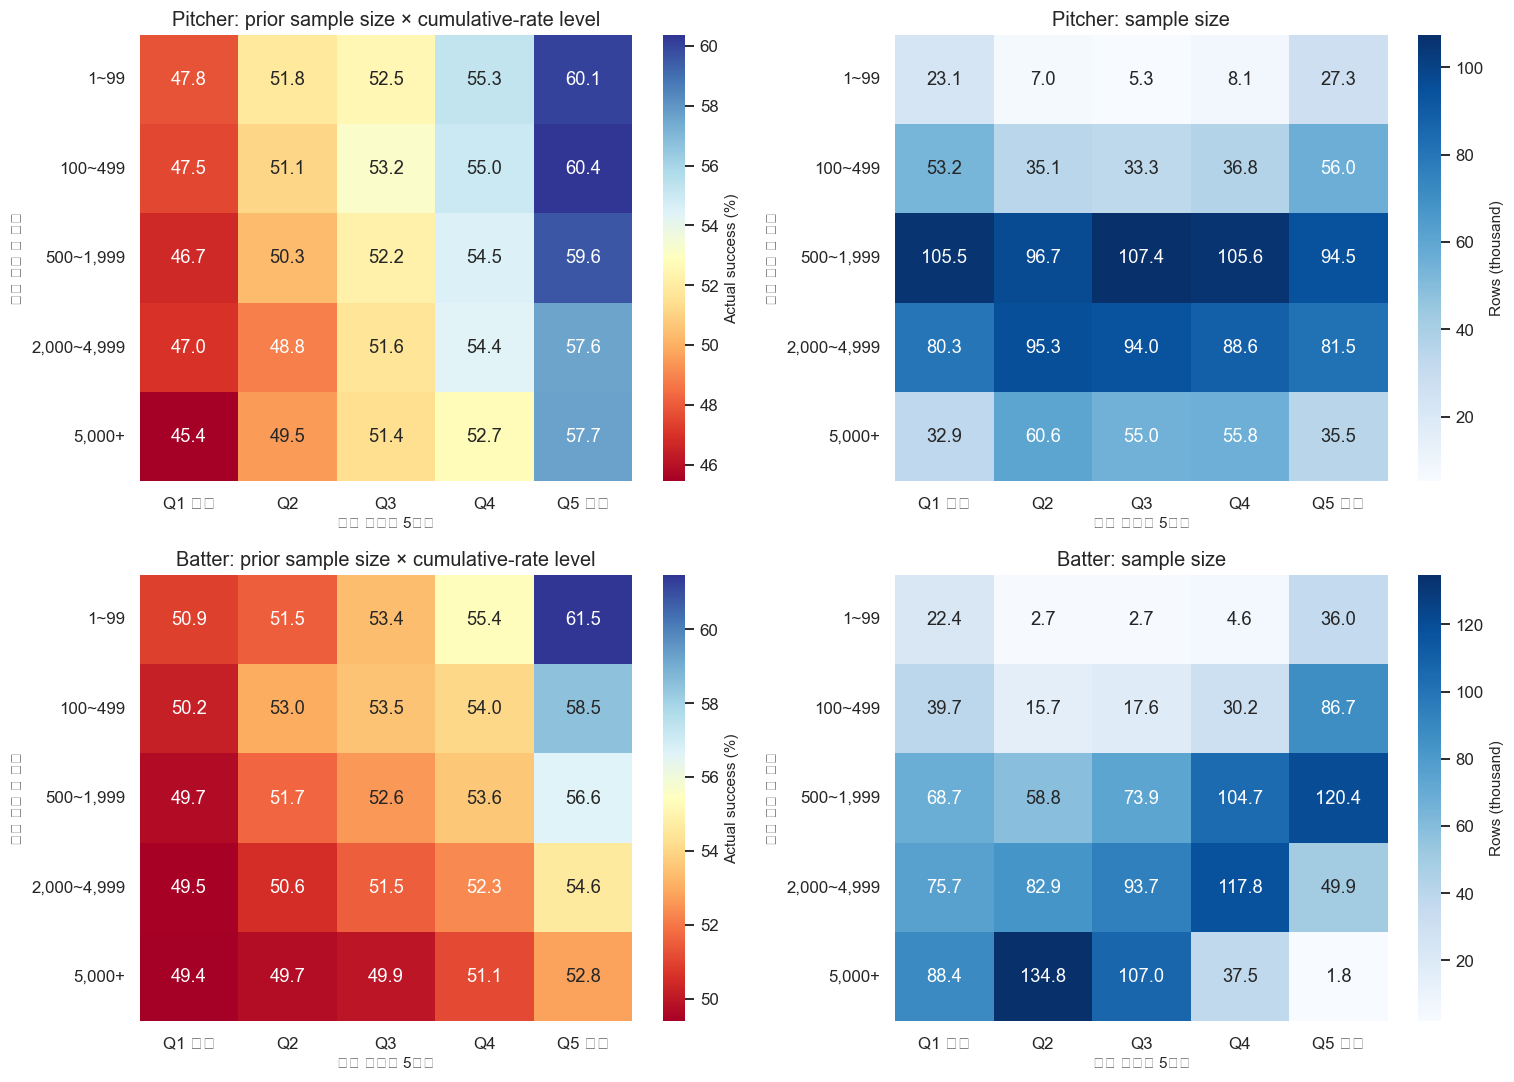


**결론:** 표본이 많아져도 누적 성공률 평균이 현재 실제 성공률을 자동으로 맞추지는 않는다. 5,000구 이상 구간에서 투수 누적률은 실제보다 **2.02%p**, 타자 누적률은 **2.25%p** 높다. 시즌 하락이 누적값에 늦게 반영된 영향이 섞여 있으므로 ID, 과거 표본 수, 누적률과 시즌을 함께 검증한다. ID 포함/제외 모델 실험은 별도의 모델링 단계다.


In [18]:
history_n_bins = [-1, 0, 99, 499, 1999, 4999, np.inf]
history_n_labels = ["0", "1~99", "100~499", "500~1,999", "2,000~4,999", "5,000+"]

id_history_summaries = []
id_history_heatmaps = {}
for entity, id_col, n_col, rate_col, name in [
    ("pitcher", "pitcher_id", "asof_pitcher_n", "asof_pitcher_success_rate", "투수"),
    ("batter", "batter_id", "asof_batter_n", "asof_batter_success_rate", "타자"),
]:
    work = df[[id_col, n_col, rate_col, TARGET]].copy()
    work["과거 표본 수 구간"] = pd.cut(work[n_col], bins=history_n_bins, labels=history_n_labels, ordered=True)
    work["squared_error"] = (work[rate_col] - work[TARGET]) ** 2
    summary = work.groupby("과거 표본 수 구간", observed=True).agg(
        투구_수=(TARGET, "size"),
        포함_ID_수=(id_col, "nunique"),
        누적_성공률_평균=(rate_col, "mean"),
        실제_성공률=(TARGET, "mean"),
        Brier=("squared_error", "mean"),
    ).reset_index()
    summary.insert(0, "구분", name)
    id_history_summaries.append(summary)

    valid = work.dropna(subset=[rate_col]).copy()
    valid["누적 성공률 5구간"] = pd.qcut(valid[rate_col], 5, labels=["Q1 낮음", "Q2", "Q3", "Q4", "Q5 높음"], duplicates="drop")
    cube = valid.groupby(["과거 표본 수 구간", "누적 성공률 5구간"], observed=True)[TARGET].agg(n="size", rate="mean").reset_index()
    id_history_heatmaps[entity] = (
        cube.pivot(index="과거 표본 수 구간", columns="누적 성공률 5구간", values="rate") * 100,
        cube.pivot(index="과거 표본 수 구간", columns="누적 성공률 5구간", values="n"),
    )

id_history_summary = pd.concat(id_history_summaries, ignore_index=True)
id_history_display = id_history_summary.copy()
for col in ["누적_성공률_평균", "실제_성공률"]:
    id_history_display[col] = id_history_display[col] * 100
display(id_history_display.rename(columns={"누적_성공률_평균": "누적 성공률 평균(%)", "실제_성공률": "실제 성공률(%)"}))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for row, (entity, title) in enumerate([("pitcher", "Pitcher"), ("batter", "Batter")]):
    rate_map, n_map = id_history_heatmaps[entity]
    sns.heatmap(rate_map, annot=True, fmt=".1f", cmap="RdYlBu", ax=axes[row, 0], cbar_kws={"label": "Actual success (%)"})
    axes[row, 0].set_title(f"{title}: prior sample size × cumulative-rate level")
    sns.heatmap(n_map / 1000, annot=True, fmt=".1f", cmap="Blues", ax=axes[row, 1], cbar_kws={"label": "Rows (thousand)"})
    axes[row, 1].set_title(f"{title}: sample size")
fig.tight_layout()
fig.savefig(EDA_ASSET_DIR / "group1_ext_id_history_combination.svg", bbox_inches="tight")
plt.show()

pitcher_high_n = id_history_summary.loc[id_history_summary["구분"].eq("투수") & id_history_summary["과거 표본 수 구간"].astype(str).eq("5,000+")].iloc[0]
batter_high_n = id_history_summary.loc[id_history_summary["구분"].eq("타자") & id_history_summary["과거 표본 수 구간"].astype(str).eq("5,000+")].iloc[0]
display(Markdown(f"""
**결론:** 표본이 많아져도 누적 성공률 평균이 현재 실제 성공률을 자동으로 맞추지는 않는다. 5,000구 이상 구간에서 투수 누적률은 실제보다 **{(pitcher_high_n['누적_성공률_평균']-pitcher_high_n['실제_성공률'])*100:.2f}%p**, 타자 누적률은 **{(batter_high_n['누적_성공률_평균']-batter_high_n['실제_성공률'])*100:.2f}%p** 높다. 시즌 하락이 누적값에 늦게 반영된 영향이 섞여 있으므로 ID, 과거 표본 수, 누적률과 시즌을 함께 검증한다. ID 포함/제외 모델 실험은 별도의 모델링 단계다.
"""))

## 5. 팀 ID와 상대 팀 조합

팀별 차이가 안정적인 맞대결 정보인지, 작은 표본과 선수 이동·선수 구성 변화가 만든 차이인지 확인한다.


### 5.1 투수 팀 × 타자 팀

**목적:** 관측된 팀 조합 사이의 성공률 차이와 표본 안정성을 확인한다.

**방법:** 관측된 모든 투수 팀×타자 팀 조합의 성공률과 투구 수를 함께 표시한다.


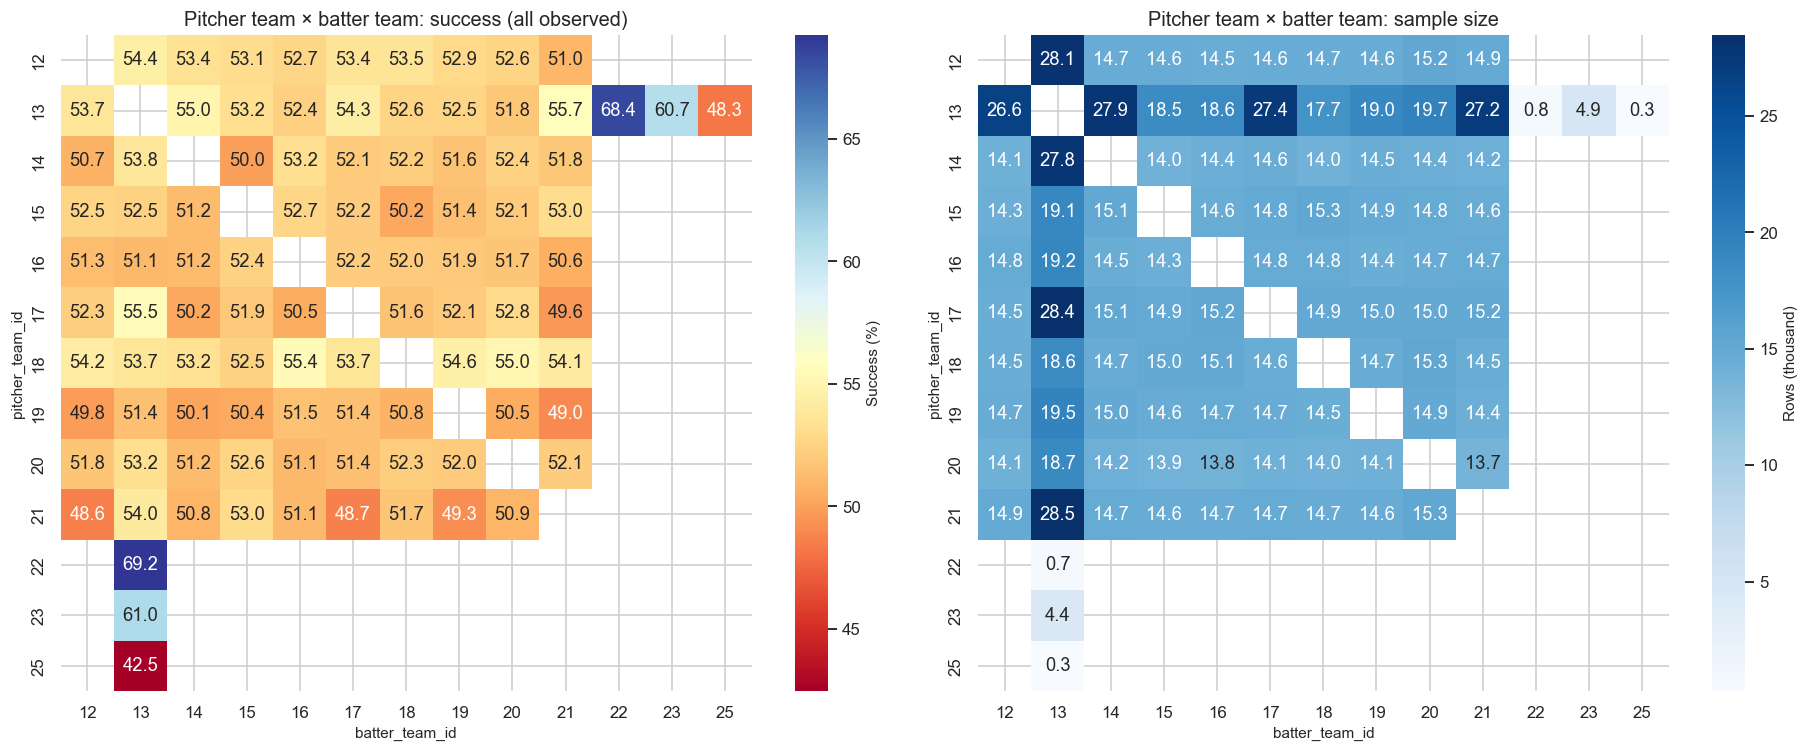

,투수 팀 ID,타자 팀 ID,투구 수,제구 성공 투구 수,제구 성공률(%),95% 신뢰구간 하한(%),95% 신뢰구간 상한(%)
95,25,13,292,124,42.4658,36.9301,48.1970
20,13,25,292,141,48.2877,42.6155,54.0043
84,21,12,14901,7237,48.5672,47.7652,49.3700
89,21,17,14749,7186,48.7219,47.9157,49.5289
74,19,21,14373,7047,49.0294,48.2125,49.8469
17,13,21,27246,15166,55.6632,55.0726,56.2523
19,13,23,4885,2967,60.7369,59.3596,62.0974
94,23,13,4437,2706,60.9872,59.5430,62.4123
18,13,22,773,529,68.4347,65.0739,71.6132
93,22,13,676,468,69.2308,65.6510,72.5932



**결론:** 관측된 팀 매치업의 성공률 범위는 **42.47%~69.23%**지만, 양끝 조합은 각각 **292구**, **676구**다. 모든 조합을 보여주되 작은 표본의 극단값을 고정된 팀 능력으로 해석하지 않고, 시즌을 함께 넣었을 때 검증 성능이 좋아지는지만 확인한다.


In [19]:
team_matchup = aggregate_rate(df, ["pitcher_team_id", "batter_team_id"])
team_rate = team_matchup.pivot(index="pitcher_team_id", columns="batter_team_id", values="success_rate") * 100
team_n = team_matchup.pivot(index="pitcher_team_id", columns="batter_team_id", values="n")
fig, axes = plt.subplots(1, 2, figsize=(17, 7))
sns.heatmap(team_rate, annot=True, fmt=".1f", cmap="RdYlBu", ax=axes[0], cbar_kws={"label": "Success (%)"})
axes[0].set_title("Pitcher team × batter team: success (all observed)")
sns.heatmap(team_n / 1000, annot=True, fmt=".1f", cmap="Blues", ax=axes[1], cbar_kws={"label": "Rows (thousand)"})
axes[1].set_title("Pitcher team × batter team: sample size")
fig.tight_layout()
fig.savefig(EDA_ASSET_DIR / "group1_ext_team_matchup.svg", bbox_inches="tight")
plt.show()

observed_team = team_matchup.sort_values("success_rate")
team_extremes = pd.concat([observed_team.head(5), observed_team.tail(5)])
display(readable_rate_table(team_extremes, {"pitcher_team_id": "투수 팀 ID", "batter_team_id": "타자 팀 ID"}))



display(Markdown(f"""
**결론:** 관측된 팀 매치업의 성공률 범위는 **{observed_team['success_rate'].min():.2%}~{observed_team['success_rate'].max():.2%}**지만, 양끝 조합은 각각 **{int(observed_team.iloc[0]['n']):,}구**, **{int(observed_team.iloc[-1]['n']):,}구**다. 모든 조합을 보여주되 작은 표본의 극단값을 고정된 팀 능력으로 해석하지 않고, 시즌을 함께 넣었을 때 검증 성능이 좋아지는지만 확인한다.
"""))


### 5.2 선수 이동

**목적:** 팀 ID가 선수에게 고정된 속성인지 확인한다.

**방법:** 투수별 관측 팀 수와 같은 시즌 안에서 여러 팀으로 관측된 투수-시즌 조합을 집계한다.


In [20]:
pitcher_team_history = df.groupby("pitcher_id", observed=True).agg(
    rows=(TARGET, "size"),
    first_season=("season", "min"),
    last_season=("season", "max"),
    n_seasons=("season", "nunique"),
    n_teams=("pitcher_team_id", "nunique"),
).reset_index()
team_lists = df.groupby("pitcher_id", observed=True)["pitcher_team_id"].agg(
    lambda x: ", ".join(map(str, sorted(pd.unique(x))))
).rename("teams").reset_index()
pitcher_team_history = pitcher_team_history.merge(team_lists, on="pitcher_id")
movers = pitcher_team_history.query("n_teams > 1").sort_values(["n_teams", "rows"], ascending=False)

same_season_multi_team = (
    df.groupby(["pitcher_id", "season"], observed=True)["pitcher_team_id"].nunique().gt(1).sum()
)
team_movement_summary = pd.Series({
    "pitchers_total": len(pitcher_team_history),
    "pitchers_with_multiple_teams": len(movers),
    "multi_team_pitcher_pct": len(movers) / len(pitcher_team_history) * 100,
    "pitcher_seasons_with_multiple_teams": int(same_season_multi_team),
})
display(team_movement_summary.rename(index={
    "pitchers_total": "전체 투수 수",
    "pitchers_with_multiple_teams": "여러 팀에서 관측된 투수 수",
    "multi_team_pitcher_pct": "여러 팀에서 관측된 투수 비율(%)",
    "pitcher_seasons_with_multiple_teams": "같은 시즌에 여러 팀에서 관측된 투수-시즌 조합 수",
}).to_frame("값"))
display(movers.head(20).rename(columns={
    "pitcher_id": "투수 ID",
    "rows": "해당 투수의 전체 투구 수",
    "first_season": "처음 관측된 시즌",
    "last_season": "마지막 관측 시즌",
    "n_seasons": "관측 시즌 수",
    "n_teams": "관측 팀 수",
    "teams": "관측된 팀 ID 목록",
}))

,값
전체 투수 수,792.0000
여러 팀에서 관측된 투수 수,164.0000
여러 팀에서 관측된 투수 비율(%),20.7071
같은 시즌에 여러 팀에서 관측된 투수-시즌 조합 수,46.0000


,투수 ID,해당 투수의 전체 투구 수,처음 관측된 시즌,마지막 관측 시즌,관측 시즌 수,관측 팀 수,관측된 팀 ID 목록
45,22028,4026,2019,2024,6,4,"12, 14, 18, 19"
25,21789,5314,2019,2024,6,3,"14, 15, 21"
6,21372,4455,2019,2024,6,3,"13, 15, 21"
10,21432,3741,2019,2024,6,3,"13, 17, 18"
77,22302,3542,2019,2024,6,3,"13, 16, 20"
69,22253,3007,2019,2024,6,3,"13, 15, 17"
152,22761,2928,2019,2024,6,3,"12, 16, 19"
360,23614,2875,2019,2023,5,3,"15, 16, 19"
167,22840,2795,2019,2024,6,3,"12, 13, 19"
365,23627,2597,2019,2024,6,3,"15, 17, 21"


**출력 해설 — 여러 팀에서 관측된 투수**

- **첫 번째 표:** 전체 투수 중 여러 팀에서 관측된 투수의 수와 비중, 같은 시즌 안에서 여러 팀으로 기록된 투수-시즌 조합 수를 요약한다.
- **두 번째 표:** 여러 팀에서 관측된 투수를 행 수·시즌 수·팀 수와 함께 보여준다. 사례 확인용 목록이며 순위 자체가 성과 순위는 아니다.
- **이번 결과:** 792명 중 164명(20.71%)이 여러 팀에서 관측됐고, 같은 시즌 안의 복수 팀 투수-시즌 조합도 46건이다.
- **의미:** 투수 ID와 팀 ID는 서로 독립된 고정 특성이 아니다. 팀별 평균에는 선수 이동과 선수 구성 변화가 포함된다.
- **모델링 시사점:** 선수와 팀을 분리된 범주로 비교하고, 선수-시즌-팀을 하나의 문자열 범주로 외우는 방식은 미래 시즌의 새 조합에 약할 수 있다.


## 6. 단독으로는 우선순위가 낮았던 분석

전체 평균에서 차이가 보여도 경기 유형 구성이나 방향 변환 역할을 고려하면 단독 피처로서의 설명력이 작은 항목을 마지막에 확인한다.


### 6.1 요일 × 경기 유형

요일별 평균만 보면 특정 경기 유형이 특정 요일에 더 많이 편성되는 효과가 섞인다. 요일과 경기 유형을 함께 묶어 **제구 성공률과 투구 수**를 비교한다. `game_type`은 공식 설명서에 코드의 풀네임이 없으므로 F/R 코드로 유지한다.


,요일 코드(0=월요일),경기 유형 코드,투구 수,제구 성공 투구 수,제구 성공률(%),95% 신뢰구간 하한(%),95% 신뢰구간 상한(%)
0,0,F,294,188,63.9456,58.3096,69.2218
1,0,R,14460,7184,49.6819,48.8671,50.4968
2,1,F,26239,15858,60.4368,59.8436,61.0269
3,1,R,206151,106034,51.4351,51.2193,51.6508
4,2,F,27218,16465,60.4931,59.9108,61.0723
5,2,R,214538,110333,51.4282,51.2167,51.6397
6,3,F,23950,14389,60.0793,59.4575,60.6979
7,3,R,212372,109068,51.3571,51.1445,51.5696
8,4,F,31018,18518,59.7008,59.1538,60.2455
9,4,R,216944,111550,51.4188,51.2085,51.6291


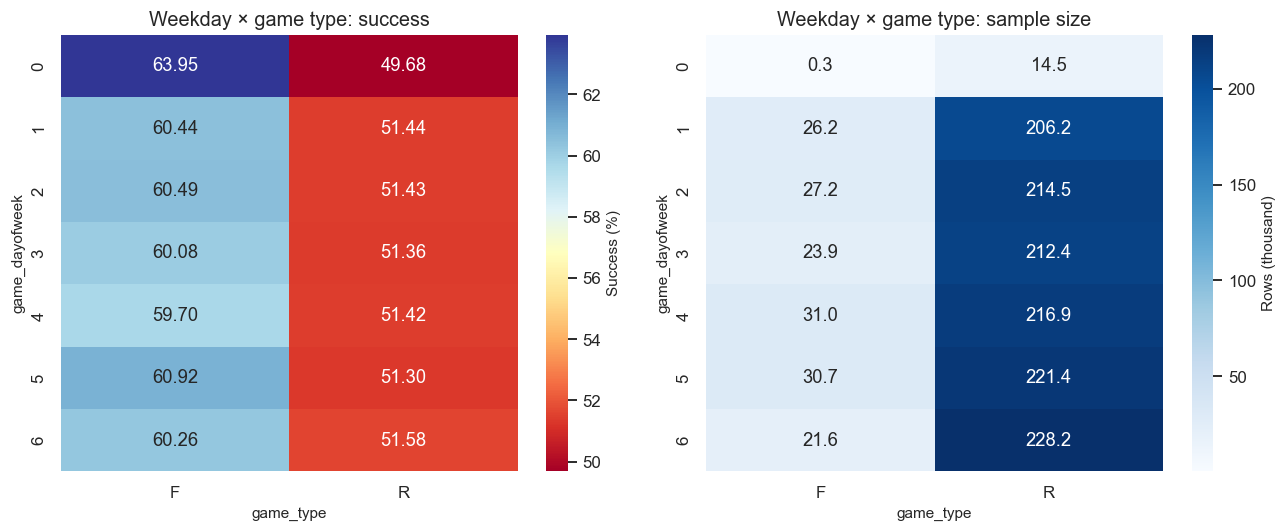


**결론:** 화~일에서 R 코드 성공률은 **51.30%~51.58%**, F 코드는 **59.70%~60.92%**로 각 유형 내부의 요일 차이는 작다. 월요일 F는 **294구**뿐이어서 63.95%를 요일 효과로 해석하지 않는다. 요일은 단독 피처 우선순위를 낮추고 경기 유형·시즌과 함께 검증한다.


In [21]:
weekday_type = aggregate_rate(df, ["game_dayofweek", "game_type"])
weekday_type_display = readable_rate_table(
    weekday_type, {"game_dayofweek": "요일 코드(0=월요일)", "game_type": "경기 유형 코드"}
)
display(weekday_type_display)

weekday_type_rate = weekday_type.pivot(index="game_dayofweek", columns="game_type", values="success_rate") * 100
weekday_type_n = weekday_type.pivot(index="game_dayofweek", columns="game_type", values="n")
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(weekday_type_rate, annot=True, fmt=".2f", cmap="RdYlBu", ax=axes[0], cbar_kws={"label": "Success (%)"})
axes[0].set_title("Weekday × game type: success")
sns.heatmap(weekday_type_n / 1000, annot=True, fmt=".1f", cmap="Blues", ax=axes[1], cbar_kws={"label": "Rows (thousand)"})
axes[1].set_title("Weekday × game type: sample size")
fig.tight_layout()
fig.savefig(EDA_ASSET_DIR / "group1_ext_weekday_game_type.svg", bbox_inches="tight")
plt.show()

regular_days = weekday_type.loc[weekday_type["game_dayofweek"].ne(0)]
display(Markdown(f"""
**결론:** 화~일에서 R 코드 성공률은 **{regular_days.loc[regular_days['game_type'].astype(str).eq('R'), 'success_rate'].min():.2%}~{regular_days.loc[regular_days['game_type'].astype(str).eq('R'), 'success_rate'].max():.2%}**, F 코드는 **{regular_days.loc[regular_days['game_type'].astype(str).eq('F'), 'success_rate'].min():.2%}~{regular_days.loc[regular_days['game_type'].astype(str).eq('F'), 'success_rate'].max():.2%}**로 각 유형 내부의 요일 차이는 작다. 월요일 F는 **{int(weekday_type.loc[weekday_type['game_dayofweek'].eq(0) & weekday_type['game_type'].astype(str).eq('F'), 'n'].iloc[0]):,}구**뿐이어서 63.95%를 요일 효과로 해석하지 않는다. 요일은 단독 피처 우선순위를 낮추고 경기 유형·시즌과 함께 검증한다.
"""))

### 6.2 초/말

**목적:** 초/말 자체의 성공률 차이와 홈 기준 점수차·기대 승률을 투수 팀 기준으로 바꾸는 방향 규칙을 확인한다.

**방법:** 초(T)·말(B)의 성공률을 표로 비교하고 점수차·기대 승률의 방향 규칙을 전체 행에서 검증한다. 이 항목은 추세 그래프보다 규칙의 일치 여부가 핵심이므로 표만 제시한다.


In [22]:
top_bottom_summary = aggregate_rate(df, "top_bottom")
display(readable_rate_table(top_bottom_summary, {"top_bottom": "초(T)·말(B)"}))

expected_pitcher_score_diff = np.where(
    df["top_bottom"].astype(str).eq("T"), df["score_diff_home"], -df["score_diff_home"]
)
score_rule_match = df["score_diff_pitcher_team"].eq(expected_pitcher_score_diff)
pitcher_team_win_expectancy = np.where(
    df["top_bottom"].astype(str).eq("T"), df["home_win_expectancy"], df["away_win_expectancy"]
)
batter_team_win_expectancy = np.where(
    df["top_bottom"].astype(str).eq("T"), df["away_win_expectancy"], df["home_win_expectancy"]
)
expectancy_sum_error = np.abs(df["home_win_expectancy"] + df["away_win_expectancy"] - 100)

direction_rule_summary = pd.DataFrame({
    "검증 항목": [
        "초/말에 따른 투수 팀 점수차 부호 일치",
        "홈·원정 기대 승률 합이 100에서 벗어난 최대값",
        "투수 팀과 타자 팀 ID가 같은 행",
    ],
    "결과": [
        f"{int(score_rule_match.sum()):,}/{len(df):,}행 일치 ({score_rule_match.mean():.4%})",
        f"{expectancy_sum_error.max():.4f}%p (표시 반올림 범위)",
        f"{int(df['pitcher_team_id'].eq(df['batter_team_id']).sum()):,}행",
    ],
})
display(direction_rule_summary)

display(Markdown(f"""
**결론:** 투수 팀 점수차의 부호 규칙은 **{score_rule_match.mean():.2%}** 일치한다. 초/말 자체의 성공률 차이는 작지만, 홈 기준 점수차와 기대 승률을 투수 팀 기준으로 바꾸는 데 반드시 필요한 방향 변수다. `top_bottom`은 단독 효과보다 **다른 상황 피처의 기준을 맞추는 변수**로 유지한다.
"""))


,초(T)·말(B),투구 수,제구 성공 투구 수,제구 성공률(%),95% 신뢰구간 하한(%),95% 신뢰구간 상한(%)
0,B,722280,378795,52.4443,52.3292,52.5595
1,T,752812,393808,52.3116,52.1988,52.4244


,검증 항목,결과
0,초/말에 따른 투수 팀 점수차 부호 일치,"1,475,092/1,475,092행 일치 (100.0000%)"
1,홈·원정 기대 승률 합이 100에서 벗어난 최대값,0.1000%p (표시 반올림 범위)
2,투수 팀과 타자 팀 ID가 같은 행,0행



**결론:** 투수 팀 점수차의 부호 규칙은 **100.00%** 일치한다. 초/말 자체의 성공률 차이는 작지만, 홈 기준 점수차와 기대 승률을 투수 팀 기준으로 바꾸는 데 반드시 필요한 방향 변수다. `top_bottom`은 단독 효과보다 **다른 상황 피처의 기준을 맞추는 변수**로 유지한다.


## 7. 모델링 검증 순서

1. `2019–2023 학습 → 2024 검증`을 고정한다.
2. 시즌별 확률 보정과 `inning`의 추가 성능을 먼저 확인한다.
3. `inning × li × score_diff_pitcher_team × 주자 상태`를 조건부 상호작용으로 검증한다.
4. `pitcher_hand × batter_hand × 과거 구종군 비율`을 검증한다.
5. 선수 ID는 과거 표본 수·누적 성공률·시즌과 함께 넣고 ID 포함/제외 성능을 비교한다. 최근 성공률은 후속 모델링에서 별도로 비교한다.
6. 경기 유형·월·팀 ID는 시즌과 함께 넣었을 때의 추가 성능만 확인한다.
7. 요일과 초/말은 마지막에 추가한다.

평가 데이터의 다른 행을 이용해 선수·팀 빈도나 타깃 평균을 새로 만들지 않고, 투구 직전까지 계산된 공식 `asof_*` 피처만 사용한다.


## 8. 분석 범위와 데이터 품질

- 분석 단위: 투구 직전 상태 1행
- 타깃: `control_success` — 1은 제구 성공, 0은 실패
- 전체 투구 수: 1,475,092
- `row_id` 중복: 0건
- 그룹 1 원본 12개 피처 결측률: 모두 0%

누적·최근 성공률에는 과거 기록이 부족한 행의 결측이 있으므로 아래 표에서 시즌별 결측률을 확인한다. 최근 기록 결측은 새 선수뿐 아니라 직전 경기 수 부족도 포함한다.


In [23]:
history_cols = CUMULATIVE_RATE_COLS + RECENT_SUCCESS_COLS
history_missing = pd.DataFrame({
    season: part[history_cols].isna().mean().mul(100)
    for season, part in df.groupby("season", observed=True)
}).T
history_missing.index.name = "시즌"
display(history_missing.rename(columns=HISTORY_LABELS))

missing_range = pd.DataFrame({
    "최소 결측률(%)": history_missing.min(),
    "최대 결측률(%)": history_missing.max(),
})
display(missing_range.rename(index=HISTORY_LABELS))


,투수의 투구 직전 누적 제구 성공률,타자가 직전까지 상대한 투구의 누적 제구 성공률,투수의 직전 1경기 제구 성공률,투수의 직전 3경기 제구 성공률,투수의 직전 5경기 제구 성공률
시즌,,,,,
2019,0.1495,0.1685,5.1716,5.1716,5.1716
2020,0.0451,0.0389,1.5835,1.5835,1.5835
2021,0.0384,0.0356,1.5140,1.5140,1.5140
2022,0.0356,0.0356,1.1884,1.1884,1.1884
2023,0.0257,0.0289,1.1086,1.1086,1.1086
2024,0.0320,0.0347,1.4351,1.4351,1.4351


,최소 결측률(%),최대 결측률(%)
투수의 투구 직전 누적 제구 성공률,0.0257,0.1495
타자가 직전까지 상대한 투구의 누적 제구 성공률,0.0289,0.1685
투수의 직전 1경기 제구 성공률,1.1086,5.1716
투수의 직전 3경기 제구 성공률,1.1086,5.1716
투수의 직전 5경기 제구 성공률,1.1086,5.1716


## Sources

- `data_description.md`
- `data/train.csv`
